In [1]:
import pandas as pd
import seaborn as sns
import plotly_express as px

import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')

## 1 - Warming up

This project will be centered around the Chicago Crime & selected Census data. Start of by downloading both datasets.

Chicago crime data : https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2

Chicago census data : https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2



In [2]:
chicago_crime_2001_to_2023_df = pd.read_csv('chicago_crime.csv')
chicago_census_2008_to_2012_df = pd.read_csv('chicago_census.csv')

The census data already contains records that apply for the period 2008-2012. Now filter the crime data so that it also contains records only for the years in that period. 

**Important:** For the rest of this project, we will only work with data for the year 2008-2012.

In [3]:
# Convert the "Date" column to datetime objects
chicago_crime_2001_to_2023_df["Date"] = pd.to_datetime(chicago_crime_2001_to_2023_df["Date"])

# Filter the DataFrame to include records for 2008-2012
start_date = pd.to_datetime("2008-01-01")
end_date = pd.to_datetime("2012-12-31")

# Now "filtered_crime_data" contains only records for the years 2008-2012
chicago_crime_2001_to_2023_df = chicago_crime_2001_to_2023_df[(chicago_crime_2001_to_2023_df["Date"] >= start_date) & 
                                                              (chicago_crime_2001_to_2023_df["Date"] <= end_date)]



# 2 - Cleaning up the mess

How many duplicated rows are there in crime data set? If there are any, we remove them.

In [4]:
# Count the number of duplicated rows
num_duplicates = chicago_crime_2001_to_2023_df.duplicated().sum()

# Print the number of duplicated rows
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 0


What columns in the crime dataset has missing values, and how many are they?

In [5]:
# Looks for missing values 
missing_values = chicago_crime_2001_to_2023_df.isna().sum()
# Print missing values
print(missing_values)

ID                          0
Case Number                 0
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description     1043
Arrest                      0
Domestic                    0
Beat                        0
District                   40
Ward                       46
Community Area            854
FBI Code                    0
X Coordinate            16231
Y Coordinate            16231
Year                        0
Updated On                  0
Latitude                16231
Longitude               16231
Location                16231
dtype: int64


Now, for all the columns with missing values we've identified, chose on of the following:

        a) remove the entire row with the missing value
        b) replace the missing values with another suitable value
        c) don't do anything, leave the missing values as is

All options above are completely valid! However...

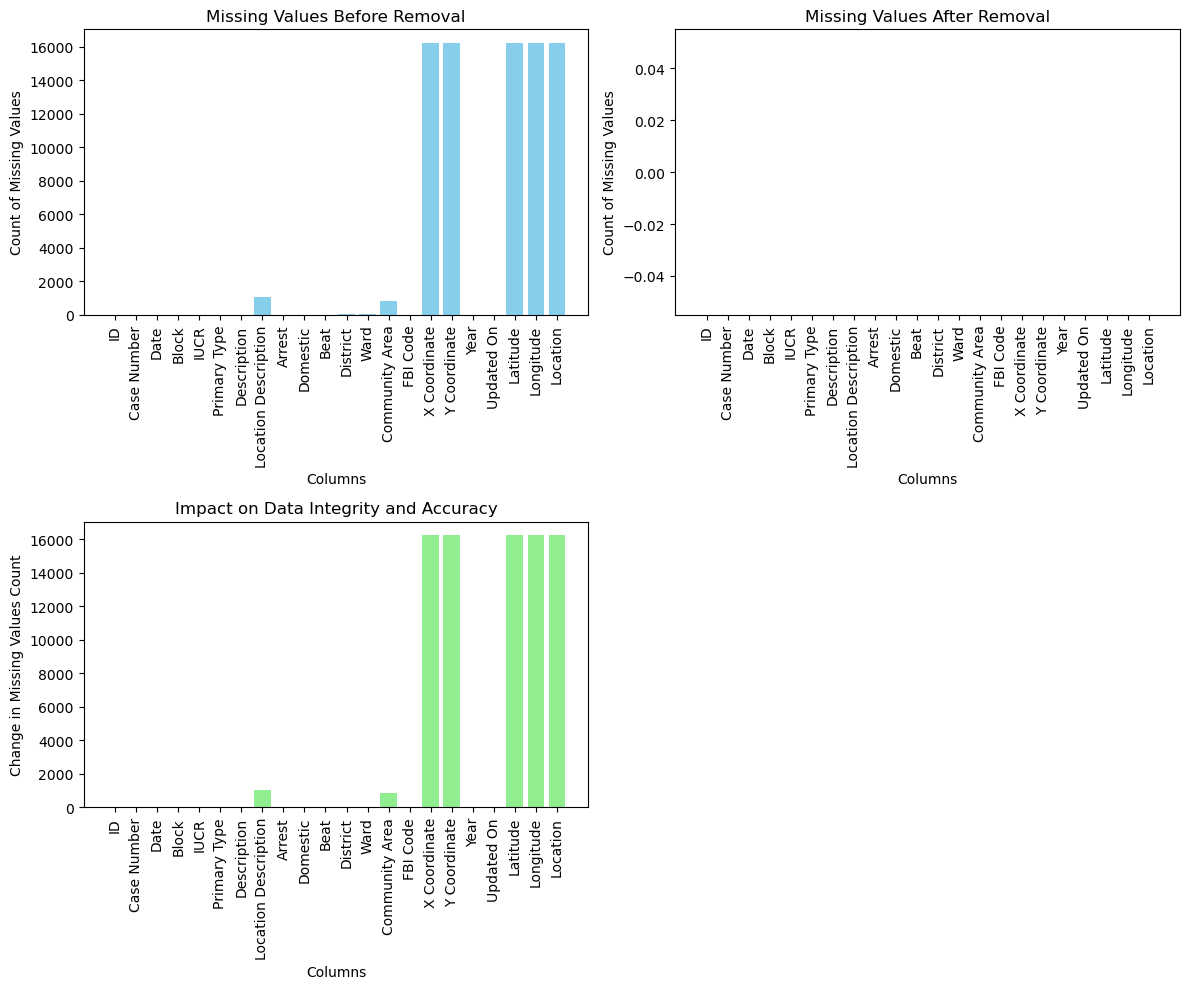

In [6]:
# Count missing values before removal
missing_values_before = chicago_crime_2001_to_2023_df.isna().sum()

# Create a figure with a 2x2 grid of subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Bar plot for missing values before removal

# .index is used to extract the column names (names of each feature or attribute) and places them on the x-axis of the graph.

# .values is used to extract the corresponding values (missing values counts for each column) and places them on the y-axis of the graph.

# the combination of .index and .values allows for the creation of a meaningful visualization of missing values in the dataset, where each bar represents a column, and the height of the bar represents the count of missing values for that column.

ax1.bar(missing_values_before.index, missing_values_before.values, color="skyblue")
ax1.set_title("Missing Values Before Removal")
ax1.set_xlabel("Columns")
ax1.set_ylabel("Count of Missing Values")

# Drops and count missing values after removal
chicago_crime_2001_to_2023_df_cleaned = chicago_crime_2001_to_2023_df.dropna()
missing_values_after = chicago_crime_2001_to_2023_df_cleaned.isna().sum()



# Bar plot for missing values after removal
ax2.bar(missing_values_after.index, missing_values_after.values, color="lightcoral")
ax2.set_title("Missing Values After Removal")
ax2.set_xlabel("Columns")
ax2.set_ylabel("Count of Missing Values")

# Bar plot for data integrity and accuracy (difference)
impact_difference = missing_values_before - missing_values_after
ax3.bar(impact_difference.index, impact_difference.values, color="lightgreen")
ax3.set_title("Impact on Data Integrity and Accuracy")
ax3.set_xlabel("Columns")
ax3.set_ylabel("Change in Missing Values Count")


# fig.delaxes(ax4) is used to remove the fourth subplot (ax4) from the overall figure (fig). The fig. delaxes() method allows for the removal of a specific subplot from the figure by providing the axes object corresponding to that subplot. In this case, the fourth subplot is not needed, so it's removed to create a cleaner layout for the three subplots.
fig.delaxes(ax4)

# Rotate x-axis labels for better readability

# In the given code snippet, plt.sca(ax) is used to set the current axes to the specified ax (axes) object, and then plt.xticks(rotation=90) is used to rotate the x-axis labels by 90 degrees for the current axes. This operation is performed for each subplot (ax1, ax2, and ax3) individually. The purpose of rotating the x-axis labels is to improve readability, especially when the labels are long or numerous.
for ax in [ax1, ax2, ax3]:
    plt.sca(ax)
    plt.xticks(rotation=90)

# Adjust subplot spacing
plt.tight_layout()

# Displays the plots
plt.show()


### Handling Missing Values: Data Integrity and Accuracy

#### **Approach to Missing Values:**

    * The decision to remove entire rows containing missing values is grounded in the principles of maintaining data integrity and accuracy. For columns related to geospatial and categorical information, imputing missing values could introduce inaccuracies and potentially skew analytical outcomes. Thus, the approach of row removal aligns with a data-driven strategy, prioritizing the reliability of the dataset.

#### **Visualizing Impact:**

    The provided code generates a set of bar plots to visually represent the impact of missing value removal:

    * The first set illustrates the count of missing values before removal (depicted in blue).
    * The second set portrays the count of missing values after removal (blank, as they have been removed).
    * The third plot (in green) presents the difference in missing values count for each column, highlighting the effect on data integrity and accuracy.

By examining these plots, we gain a clear understanding of the alterations in missing values for each column, both pre and post-removal. This visual representation aids in 
comprehending the implications for data quality and integrity resulting from the removal process.

## 3 - The Birds Eye

We will do some exploratory analysis on the dataset and try to get a sense of the data we're working with.

How many crimes records exists for the period 2008-2012, in total?

In [8]:
# Filter the DataFrame for the period 2008-2012
filtered_crime_records = chicago_crime_2001_to_2023_df[(chicago_crime_2001_to_2023_df["Date"] >= "2008-01-01") & (chicago_crime_2001_to_2023_df["Date"] <= "2012-12-31")]

# Count the number of records in the filtered DataFrame
num_records = len(filtered_crime_records)

print("Total Number of crime records for the period 2008-2012:", num_records)

Total Number of crime records for the period 2008-2012: 1878127


What's the number of recorded crimes for each of the years, individually? 

In [9]:
# Group the data by the "Year" column and count the number of records for each year
crime_records_by_year = chicago_crime_2001_to_2023_df.groupby("Year").size().reset_index(name="Number of Crimes")

# Print the result
print(crime_records_by_year)

   Year  Number of Crimes
0  2008            427185
1  2009            392828
2  2010            370518
3  2011            351997
4  2012            335599


Has the number of recorded crimes increased, decreased or remained stable throughout the years?

The number of recorded crimes has decreased throughout the years.


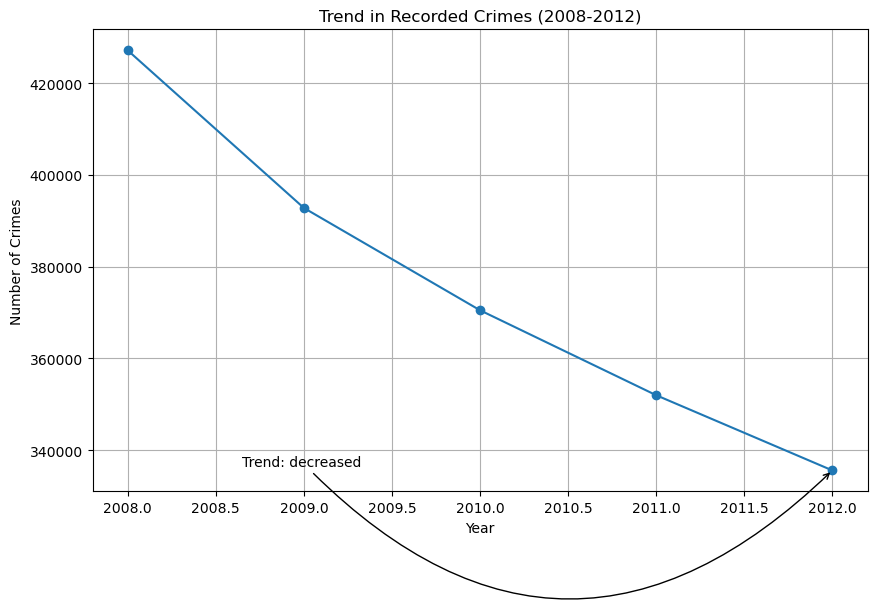

In [10]:
# Group the data by the "Year" column and count the number of records for each year
crime_records_by_year = chicago_crime_2001_to_2023_df.groupby("Year").size().reset_index(name="Number of Crimes")

# Calculate the earliest and most recent years
earliest_year = crime_records_by_year["Year"].min()
most_recent_year = crime_records_by_year["Year"].max()

# Find the number of crimes in the earliest year and most recent year
earliest_crimes = crime_records_by_year[crime_records_by_year["Year"] == earliest_year]["Number of Crimes"].values[0]
most_recent_crimes = crime_records_by_year[crime_records_by_year["Year"] == most_recent_year]["Number of Crimes"].values[0]

# Determine the trend
if most_recent_crimes > earliest_crimes:
    trend = "increased"
elif most_recent_crimes < earliest_crimes:
    trend = "decreased"
else:
    trend = "remained stable"

# Create a line plot to visualize the trend
plt.figure(figsize=(10, 6))
plt.plot(crime_records_by_year["Year"], crime_records_by_year["Number of Crimes"], marker="o", linestyle="-")
plt.title(f"Trend in Recorded Crimes ({earliest_year}-{most_recent_year})")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.grid(True)

# Annotate the plot with the trend information

# adding an annotation to the plot, displaying the trend information, and using an arrow to point to the most recent data point on the plot. The xy argument sets the location of the arrow, and xytext sets the location of the text label.

# xy=(most_recent_year, most_recent_crimes): This specifies the point in the plot where the arrow will point to. In this case, it's the coordinates (x, y) representing the most recent year and the corresponding number of crimes.


# xytext is an argument used in the plt.annotate function to specify the coordinates for placing the text annotation in the plot. The xytext parameter takes a tuple of two values, representing the x and y coordinates where the text annotation should be placed.

# most_recent_year - 3.35: This corresponds to the x-coordinate for placing the text. It's calculated as 5 years before the most recent year, providing a little space before the arrow and text.

# most_recent_crimes + 1000: This corresponds to the y-coordinate for placing the text. It's calculated as 1000 units (crimes) above the number of crimes in the most recent year. This is to position the text slightly above the data point on the plot.

plt.annotate(f"Trend: {trend}", xy=(most_recent_year, most_recent_crimes), xytext=(most_recent_year - 3.35, most_recent_crimes + 1000),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.5"))

# Print the result
print(f"The number of recorded crimes has {trend} throughout the years.")





plt.show()

By how many percentage points has the crime rate increased/decreased during the period? 

We only need to compare the number of crime records from 2008 with the number of crime records from 2012.

The crime rate decreased by -21.44% between 2008 and 2012.


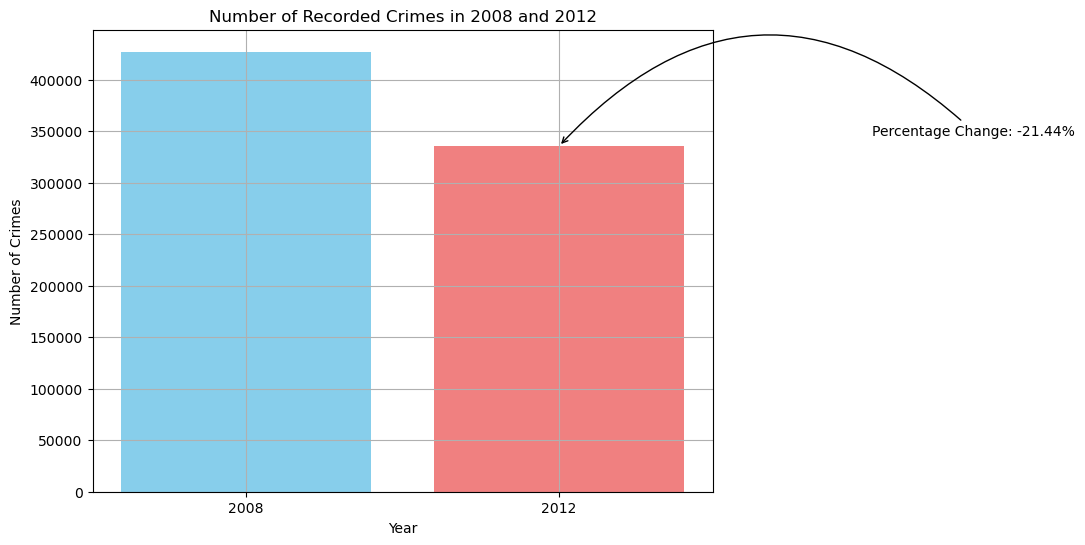

In [11]:
# Group the data by the "Year" column and count the number of records for each year
crime_records_by_year = chicago_crime_2001_to_2023_df.groupby("Year").size().reset_index(name="Number of Crimes")

# Find the number of crimes in 2008 and 2012
crime_2008 = crime_records_by_year[crime_records_by_year["Year"] == 2008]["Number of Crimes"].values[0]
crime_2012 = crime_records_by_year[crime_records_by_year["Year"] == 2012]["Number of Crimes"].values[0]

# Calculate the percentage change
percentage_change = ((crime_2012 - crime_2008) / crime_2008) * 100

# Print the result

# {percentage_change:.2f}: This is a placeholder in an f-string that is used to format the percentage_change variable. The :.2f inside the curly braces specifies that the floating-point number (percentage_change) should be formatted with two decimal places.

# For example, if percentage_change is 12.3456, using :.2f would format it as "12.35" in the output
print(f"The crime rate decreased by {percentage_change:.2f}% between 2008 and 2012.")


# Group the data by the "Year" column and count the number of records for each year
crime_records_by_year = chicago_crime_2001_to_2023_df.groupby("Year").size().reset_index(name="Number of Crimes")

# Find the number of crimes in 2008 and 2012
crime_2008 = crime_records_by_year[crime_records_by_year["Year"] == 2008]["Number of Crimes"].values[0]
crime_2012 = crime_records_by_year[crime_records_by_year["Year"] == 2012]["Number of Crimes"].values[0]

# Create a bar plot to visualize the percentage change
plt.figure(figsize=(8, 6))
plt.bar(["2008", "2012"], [crime_2008, crime_2012], color=["skyblue", "lightcoral"])
plt.title("Number of Recorded Crimes in 2008 and 2012")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.annotate(f"Percentage Change: {percentage_change:.2f}%", xy=(1, crime_2012), xytext=(2, crime_2012 + 10000),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.5"))
plt.grid(True)


plt.show()


Which primary crime types have increasing crime record numbers, and which ones have decreasing, when comparing 2008 to 2012?

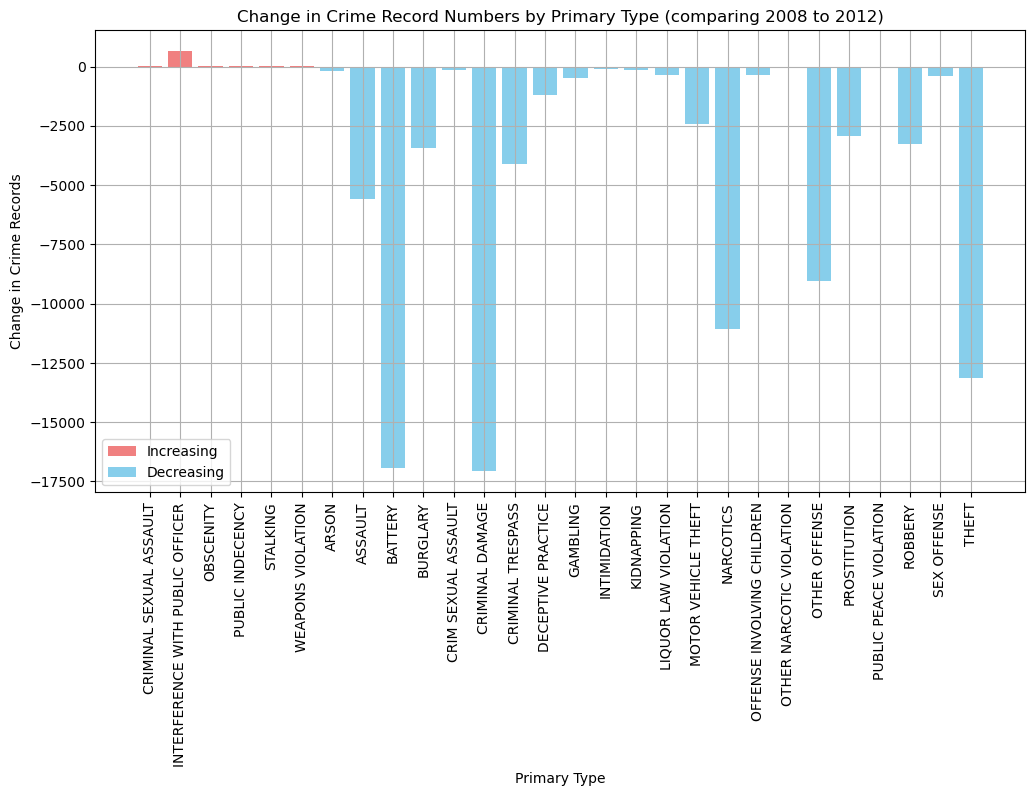

In [12]:
# Filter the DataFrame for the year 2008 and 2012
filtered_crime_records_2008 = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == 2008]
filtered_crime_records_2012 = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == 2012]

# Group the data by "Primary Type" and count the number of records for each year
crime_records_by_type_2008 = filtered_crime_records_2008["Primary Type"].value_counts()
crime_records_by_type_2012 = filtered_crime_records_2012["Primary Type"].value_counts()

# Calculate the change for each primary crime type between 2008 and 2012
crime_records_change = crime_records_by_type_2012 - crime_records_by_type_2008

# Separate the types with increasing and decreasing records
increasing_types = crime_records_change[crime_records_change > 0]
decreasing_types = crime_records_change[crime_records_change < 0]

# Create a bar plot to visualize the change in crime record numbers
plt.figure(figsize=(12, 6))
plt.bar(increasing_types.index, increasing_types.values, color="lightcoral", label="Increasing")
plt.bar(decreasing_types.index, decreasing_types.values, color="skyblue", label="Decreasing")
plt.title("Change in Crime Record Numbers by Primary Type (comparing 2008 to 2012)")
plt.xlabel("Primary Type")
plt.ylabel("Change in Crime Records")
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)


plt.show()


Which are the top 5 primary crime types in terms of increasing crime records between 2008 and 2012? Which are the top 5 primary crime types in terms of *percentual* increase? 

Are the top 5 lists you just produced different? If so, why?   

Top 5 Primary Crime Types with Increasing Records (Absolute Increase):
Primary Type
INTERFERENCE WITH PUBLIC OFFICER    648
CRIMINAL SEXUAL ASSAULT              19
WEAPONS VIOLATION                    18
STALKING                             16
OBSCENITY                            13
Name: count, dtype: int32

Top 5 Primary Crime Types with the Highest Percentual Increase:
Primary Type
PUBLIC INDECENCY                    325
INTERFERENCE WITH PUBLIC OFFICER    111
OBSCENITY                           100
CRIMINAL SEXUAL ASSAULT              39
STALKING                              8
Name: count, dtype: int32


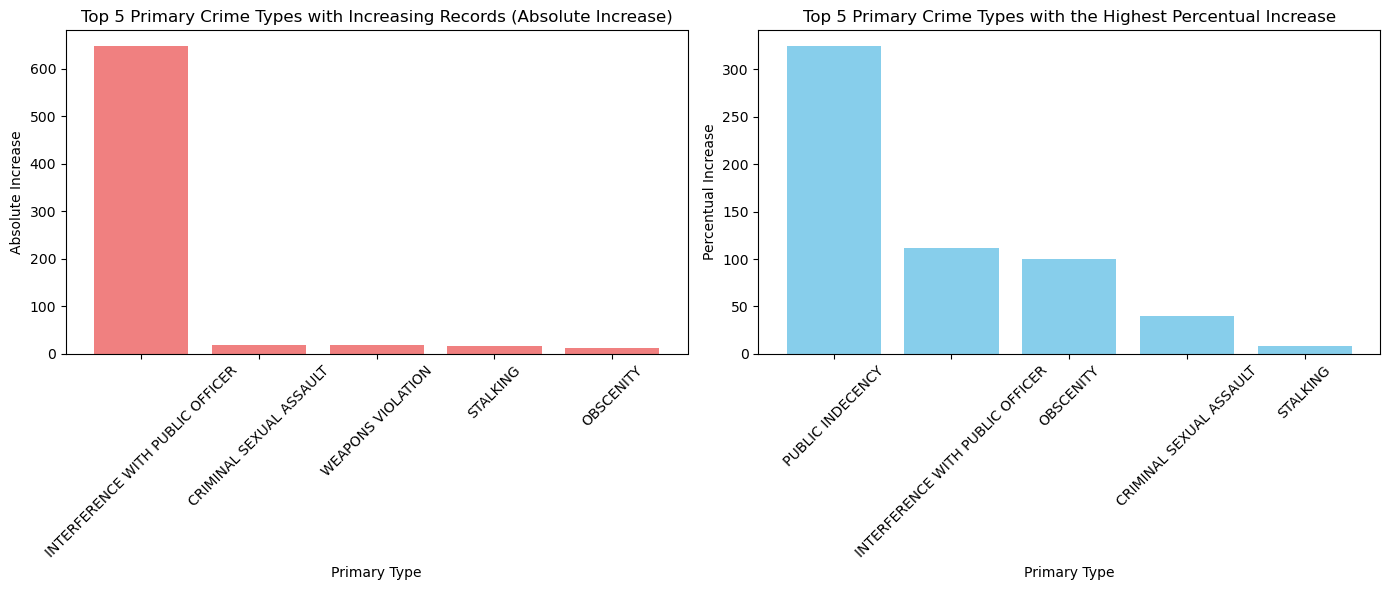

In [13]:
# Filter the DataFrame for the year 2008 and 2012
filtered_crime_records_2008 = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == 2008]
filtered_crime_records_2012 = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == 2012]

# Group the data by "Primary Type" and count the number of records for each year
crime_records_by_type_2008 = filtered_crime_records_2008["Primary Type"].value_counts()
crime_records_by_type_2012 = filtered_crime_records_2012["Primary Type"].value_counts()

# Calculate the change for each primary crime type between 2008 and 2012
crime_records_change = crime_records_by_type_2012 - crime_records_by_type_2008


# Get the top 5 primary crime types with increasing records (absolute increase)
top_5_increasing_types = crime_records_change.nlargest(5)
print("Top 5 Primary Crime Types with Increasing Records (Absolute Increase):")
print((top_5_increasing_types).astype(int))


# Calculate the percentage increase for each primary crime type between 2008 and 2012
percentage_increase = ((crime_records_by_type_2012 - crime_records_by_type_2008) / crime_records_by_type_2008 * 100)


# Get the top 5 primary crime types with the highest percentual increase
top_5_percentual_increase = percentage_increase.nlargest(5)

print()
print("Top 5 Primary Crime Types with the Highest Percentual Increase:")
print((top_5_percentual_increase).astype(int))


# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Create bar plots for the top 5 primary crime types with increasing records (absolute increase)
ax1.bar(top_5_increasing_types.index, top_5_increasing_types.values, color="lightcoral")
ax1.set_title("Top 5 Primary Crime Types with Increasing Records (Absolute Increase)")
ax1.set_xlabel("Primary Type")
ax1.set_ylabel("Absolute Increase")

# Create bar plots for the top 5 primary crime types with the highest percentual increase
ax2.bar(top_5_percentual_increase.index, top_5_percentual_increase.values, color="skyblue")
ax2.set_title("Top 5 Primary Crime Types with the Highest Percentual Increase")
ax2.set_xlabel("Primary Type")
ax2.set_ylabel("Percentual Increase")

# Rotate x-axis labels for better readability
for ax in [ax1, ax2]:
    plt.sca(ax)
    plt.xticks(rotation=45)


plt.tight_layout()


plt.show()


# 4 - Chicago Police Departement performance assessment

How many recorded crimes have in total led to an arrest? What's the corresponding arrest percentage?

Total recorded crimes with arrests: 508213
Arrest Percentage: 27.059565194473006 %


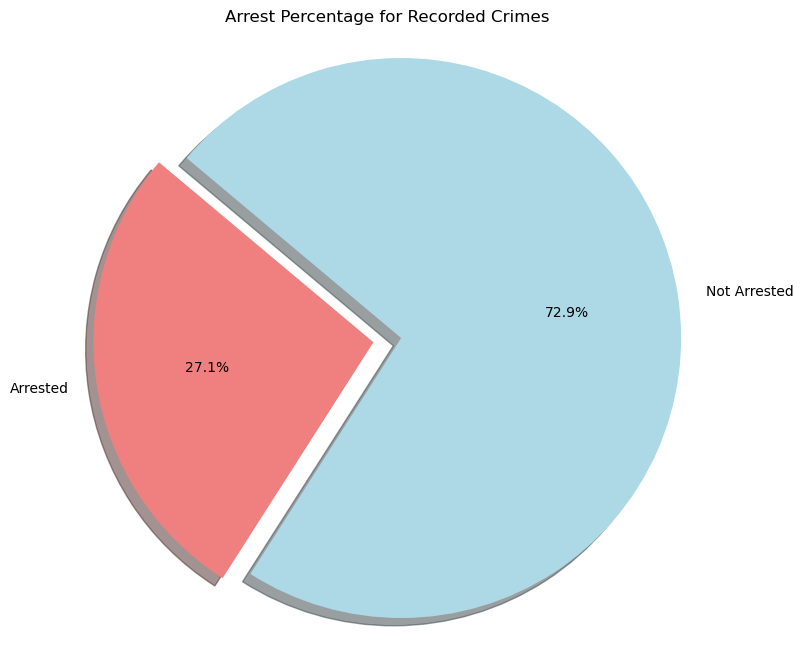

In [14]:
# Count the total number of recorded crimes
total_crimes = len(chicago_crime_2001_to_2023_df)

# Filter the DataFrame to include only records where an arrest was made
arrested_crimes = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Arrest"] == True]

# Count the number of recorded crimes that led to an arrest
arrested_count = len(arrested_crimes)

# Calculate the arrest percentage
arrest_percentage = (arrested_count / total_crimes) * 100

print("Total recorded crimes with arrests:", arrested_count)
print("Arrest Percentage:", arrest_percentage, "%")


# Create a pie chart to visualize the arrest percentage
labels = ["Arrested", "Not Arrested"]
sizes = [arrest_percentage, 100 - arrest_percentage]
colors = ["lightcoral", "lightblue"]
# Explode the "Arrested" slice
explode = (0.1, 0)  

plt.figure(figsize=(8, 8))

# sizes: This parameter represents the sizes of the slices in the pie chart. In this case, it is a list containing two elements: arrest_percentage and 100 - arrest_percentage. These values determine the size of the "Arrested" and "Not Arrested" slices, respectively.

# explode: This parameter is used to "explode" or separate a particular slice from the rest of the pie.
# In this code, the explode tuple is set to (0.1, 0), which means that the first slice ("Arrested") will be slightly separated from the rest of the pie by 10% of the radius.

# labels: This parameter specifies the labels for each slice in the pie chart. In this case, the labels are "Arrested" and "Not Arrested."

# colors: This parameter determines the colors of each slice. The colors list is set to ["lightcoral", "lightblue"], assigning a light coral color to the "Arrested" slice and a light blue color to the "Not Arrested" slice.

# autopct: This parameter is used to format the percentage labels on each slice. In this case, it is set to "%1.1f%%", which means the percentage will be displayed with one decimal place.

# shadow: When shadow is set to True, the pie chart will have a shadow effect, giving it a three-dimensional appearance.

# startangle: This parameter sets the angle at which the first slice of the pie starts. In this code, it is set to 140 degrees.

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct="%1.1f%%", shadow=True, startangle=140)
plt.title("Arrest Percentage for Recorded Crimes")
# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis("equal")  


plt.show()



Has the arrest rate percentage been increasing, decreasing or remained stable over these years?

The arrest rate percentage has increased over the years (2008-2012).


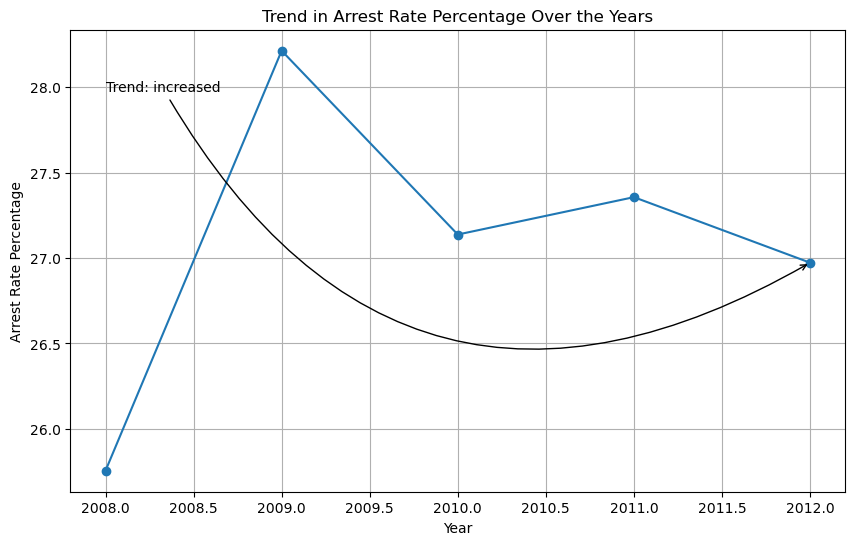

In [15]:
# Group the data by the "Year" column and count the number of records for each year
crime_records_by_year = chicago_crime_2001_to_2023_df.groupby("Year").size().reset_index(name="Total Crimes")

# Group the data by the "Year" column and count the number of records with arrests for each year
arrested_crimes_by_year = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Arrest"] == True].groupby("Year").size().reset_index(name="Arrested Crimes")

# Merge the two dataframes on "Year" to calculate the arrest rate percentage
merged_df = crime_records_by_year.merge(arrested_crimes_by_year, on="Year")

# Calculate the arrest rate percentage for each year
merged_df["Arrest Rate Percentage"] = (merged_df["Arrested Crimes"] / merged_df["Total Crimes"]) * 100

# Determine the trend in arrest rate percentage
earliest_year = merged_df["Year"].min()
most_recent_year = merged_df["Year"].max()

earliest_arrest_rate = merged_df[merged_df["Year"] == earliest_year]["Arrest Rate Percentage"].values[0]
most_recent_arrest_rate = merged_df[merged_df["Year"] == most_recent_year]["Arrest Rate Percentage"].values[0]

if most_recent_arrest_rate > earliest_arrest_rate:
    trend = "increased"
elif most_recent_arrest_rate < earliest_arrest_rate:
    trend = "decreased"
else:
    trend = "remained stable"

# Print the result
print(f"The arrest rate percentage has {trend} over the years ({earliest_year}-{most_recent_year}).")


# Plot the trend in arrest rate percentage
plt.figure(figsize=(10, 6))
plt.plot(merged_df["Year"], merged_df["Arrest Rate Percentage"], marker="o", linestyle="-")
plt.title("Trend in Arrest Rate Percentage Over the Years")
plt.xlabel("Year")
plt.ylabel("Arrest Rate Percentage")
plt.grid(True)

# Annotate the plot with the trend information
plt.annotate(f"Trend: {trend}", xy=(most_recent_year, most_recent_arrest_rate), 
             xytext=(most_recent_year - 4, most_recent_arrest_rate + 1),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.5"))


plt.show()


For the Year 2011, which month has the highest arrest percentage?

Month with the highest arrest percentage in 2011: 3
Highest arrest percentage: 29.304578078182704


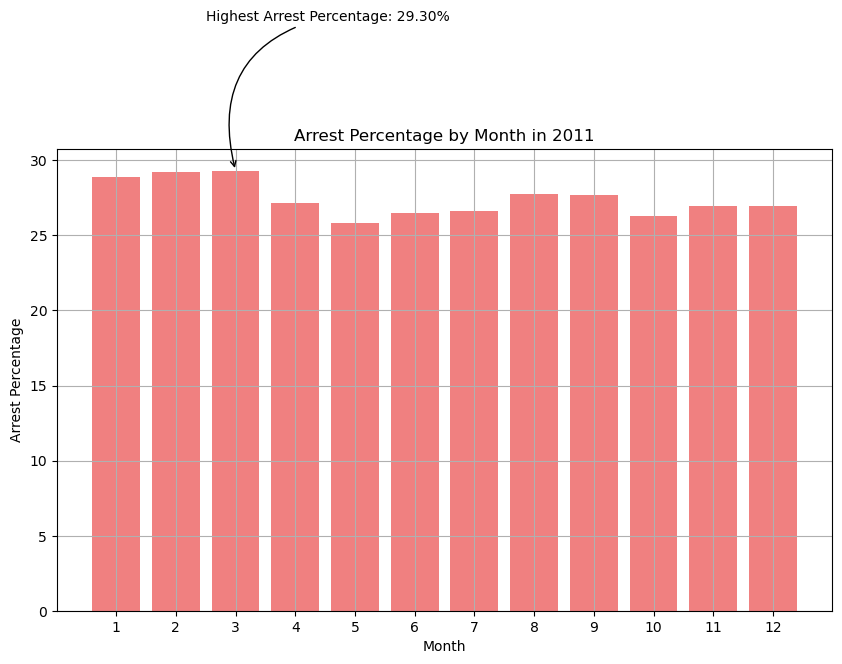

In [16]:
# Filter the DataFrame for the year 2011
crime_records_2011 = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == 2011]

# Group the data by month and calculate total crimes and arrests for each month
crime_records_by_month = crime_records_2011.groupby(crime_records_2011["Date"].dt.month)["Arrest"].agg(["count", "sum"]).reset_index()

# Calculate arrest percentage for each month
crime_records_by_month['Arrest Percentage'] = (crime_records_by_month["sum"] / crime_records_by_month["count"]) * 100

# Identify the month with the highest arrest percentage
highest_arrest_month = crime_records_by_month.loc[crime_records_by_month["Arrest Percentage"].idxmax()]

print("Month with the highest arrest percentage in 2011:", round(highest_arrest_month["Date"]))
print("Highest arrest percentage:", highest_arrest_month["Arrest Percentage"])

# Plot the arrest percentage for each month
plt.figure(figsize=(10, 6))
plt.bar(crime_records_by_month["Date"], crime_records_by_month["Arrest Percentage"], color="lightcoral")
plt.title("Arrest Percentage by Month in 2011")
plt.xlabel("Month")
plt.ylabel("Arrest Percentage")
plt.xticks(crime_records_by_month["Date"])
plt.grid(True)

# Annotate the plot to highlight the month with the highest arrest percentage
plt.annotate(f"Highest Arrest Percentage: {highest_arrest_month['Arrest Percentage']:.2f}%", 
             xy=(highest_arrest_month["Date"], highest_arrest_month["Arrest Percentage"]),
             xytext=(highest_arrest_month["Date"] - 0.5, highest_arrest_month["Arrest Percentage"] + 10),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.5"))


plt.show()


For the same year, and the particular month of you've identified in question 2.3, which primary crime type has the highest number of arrests?

For the same year and the specific month identified (3), the primary crime type with the highest number of arrests is:
Primary Crime Type: NARCOTICS
Number of Arrests: 3747


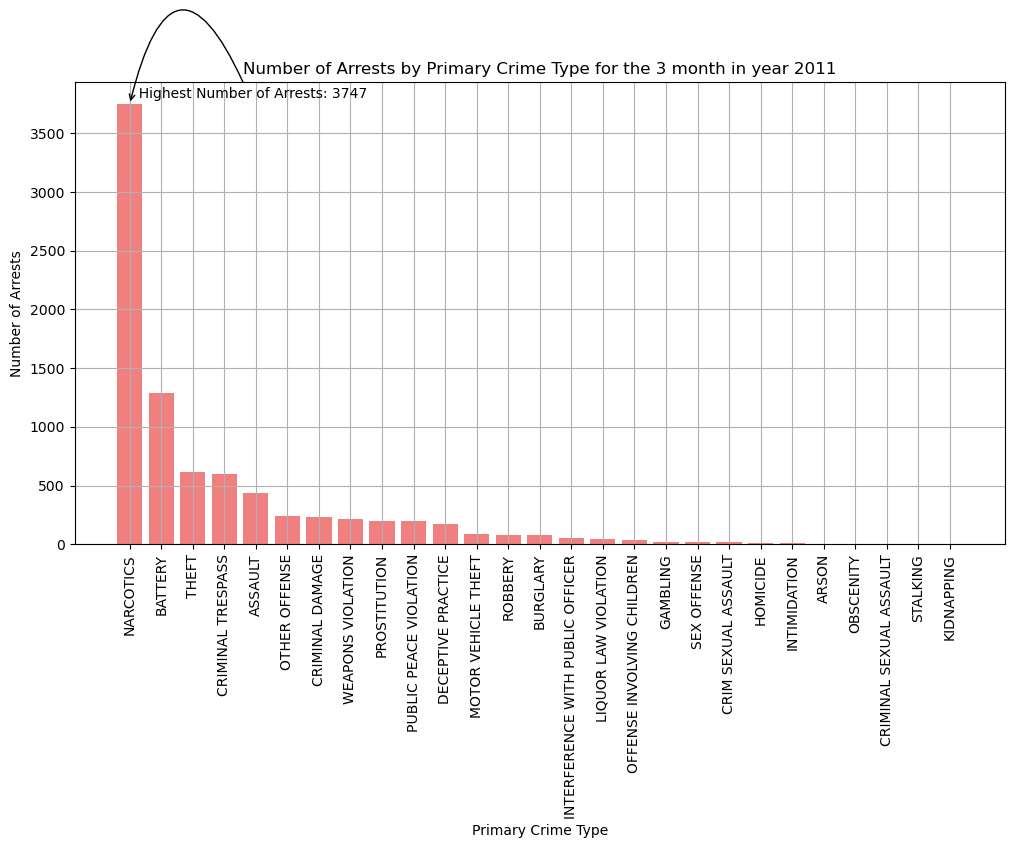

In [17]:
# Filter the data for the year 2011 and the specific month identified
crime_data_specific_month = crime_records_2011[crime_records_2011["Date"].dt.month == highest_arrest_month["Date"]]

# Group the data by "Primary Type" and count the number of arrests for each primary crime type
arrests_by_primary_type = crime_data_specific_month[crime_data_specific_month["Arrest"] == True]["Primary Type"].value_counts()

# Identify the primary crime type with the highest number of arrests
highest_arrest_primary_type = arrests_by_primary_type.idxmax()
highest_arrest_count = arrests_by_primary_type.max()

# Print the result
print(f"For the same year and the specific month identified ({round(highest_arrest_month['Date'])}), "
      f"the primary crime type with the highest number of arrests is:")
print(f"Primary Crime Type: {highest_arrest_primary_type}")
print(f"Number of Arrests: {highest_arrest_count}")

# Sort the data by the number of arrests in descending order to highlight the highest count
arrests_by_primary_type = arrests_by_primary_type.sort_values(ascending=False)

# Plot the number of arrests for each primary crime type
plt.figure(figsize=(12, 6))
plt.bar(arrests_by_primary_type.index, arrests_by_primary_type.values, color="lightcoral")
plt.title(f"Number of Arrests by Primary Crime Type for the {round(highest_arrest_month['Date'])} month in year 2011")
plt.xlabel("Primary Crime Type")
plt.ylabel("Number of Arrests")
plt.xticks(rotation=90)
plt.grid(True)

# Annotate the plot to highlight the primary crime type with the highest number of arrests
highest_primary_type = arrests_by_primary_type.idxmax()
highest_count = arrests_by_primary_type.max()
plt.annotate(f"  Highest Number of Arrests: {highest_count}", 
             xy=(highest_primary_type, highest_count),
             xytext=(highest_primary_type, highest_count + 50),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=1.5"))


plt.show()


Which primary crime categories enjoy the highest percentual increase in number of arrests, while comparing 2008 and 2012?

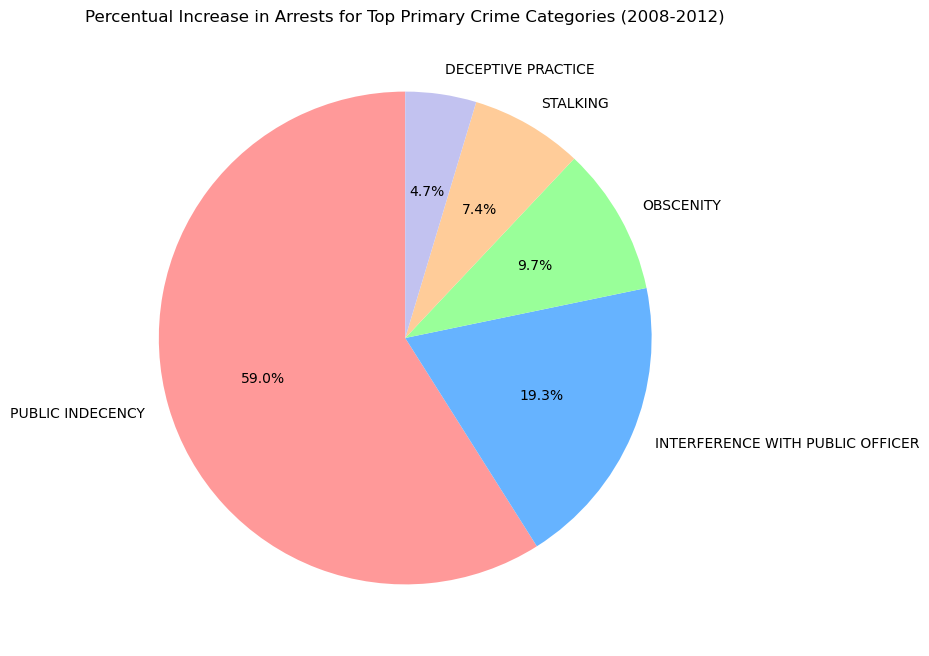

In [18]:
# Filter the data for the years 2008 and 2012
crime_data_2008 = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == 2008]
crime_data_2012 = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == 2012]

# Group the data by "Primary Type" and count the number of arrests for each primary crime category for both years
arrests_2008 = crime_data_2008[crime_data_2008["Arrest"] == True]["Primary Type"].value_counts()
arrests_2012 = crime_data_2012[crime_data_2012["Arrest"] == True]["Primary Type"].value_counts()

# Calculate the percentual increase for each primary crime category
percentual_increase = ((arrests_2012 - arrests_2008) / arrests_2008 * 100).sort_values(ascending=False)

# Find the primary crime categories with the highest percentual increase
top_percentual_increase_categories = percentual_increase.head(5)

# Find the most common location for these arrests
locations_most_arrests = crime_data_2012[crime_data_2012["Primary Type"].isin(top_percentual_increase_categories.index)]["Location Description"].value_counts().idxmax()

# Find the most common location for crimes without arrests for the same primary crime categories
locations_most_crimes_without_arrests = crime_data_2012[crime_data_2012["Primary Type"].isin(top_percentual_increase_categories.index) & (crime_data_2012["Arrest"] == False)]["Location Description"].value_counts().idxmax()

# Create a pie plot for the percentual increase in arrests for the top primary crime categories
plt.figure(figsize=(8, 8))
plt.pie(top_percentual_increase_categories, labels=top_percentual_increase_categories.index, autopct="%1.1f%%", startangle=90, colors=["#ff9999","#66b3ff","#99ff99","#ffcc99", "#c2c2f0"])
plt.title("Percentual Increase in Arrests for Top Primary Crime Categories (2008-2012)")
plt.show()


# 5 - Bad Boys Bad Boys whatcha gonna do

In general, what weekday is a crime most likely to occur? Which day is the safest?

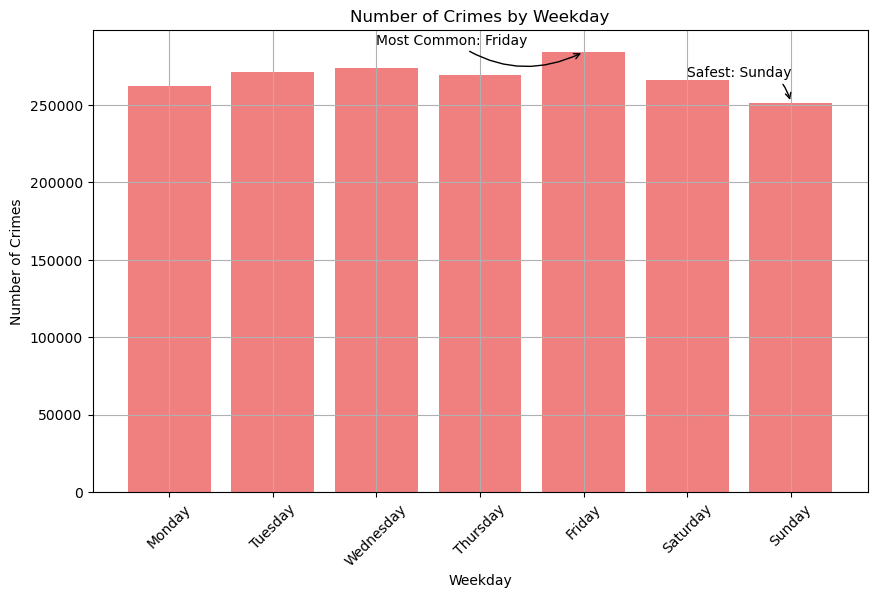

In [24]:
# Convert the "Date" column to datetime objects
chicago_crime_2001_to_2023_df["Date"] = pd.to_datetime(chicago_crime_2001_to_2023_df["Date"])

# Extract the weekday from the "Date" column and create a new "Weekday" column
chicago_crime_2001_to_2023_df["Weekday"] = chicago_crime_2001_to_2023_df["Date"].dt.weekday

# Group the data by the "Weekday" column and count the number of crimes for each weekday
crime_by_weekday = chicago_crime_2001_to_2023_df.groupby("Weekday").size().reset_index(name="Number of Crimes")

# Define weekday names for better readability
weekday_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Create a bar plot to visualize the number of crimes on each weekday
plt.figure(figsize=(10, 6))
plt.bar(weekday_names, crime_by_weekday["Number of Crimes"], color="lightcoral")
plt.title("Number of Crimes by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.grid(True)

# Annotate the plot with the most common and safest weekdays
most_common_weekday = crime_by_weekday[crime_by_weekday["Number of Crimes"] == crime_by_weekday["Number of Crimes"].max()]["Weekday"].values[0]
safest_weekday = crime_by_weekday[crime_by_weekday["Number of Crimes"] == crime_by_weekday["Number of Crimes"].min()]["Weekday"].values[0]
plt.annotate(f"Most Common: {weekday_names[most_common_weekday]}", xy=(most_common_weekday, crime_by_weekday["Number of Crimes"].max()), xytext=(most_common_weekday - 2, crime_by_weekday["Number of Crimes"].max() + 5000),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.3"))
plt.annotate(f"Safest: {weekday_names[safest_weekday]}", xy=(safest_weekday, crime_by_weekday["Number of Crimes"].min()), xytext=(safest_weekday - 1, crime_by_weekday["Number of Crimes"].min() + 17000),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.5"))


plt.show()


Which is the most unsafe weekday for us if we did like to avoid the following:

a) getting your phone stolen by sneaky pickpockets (THEFT) 

b) having your handbag forcibly pulled away (ROBBERY) 

c) getting jumped in an alley (ASSAULT)

For each of the above crimes, also at what locations should we be extra careful around.

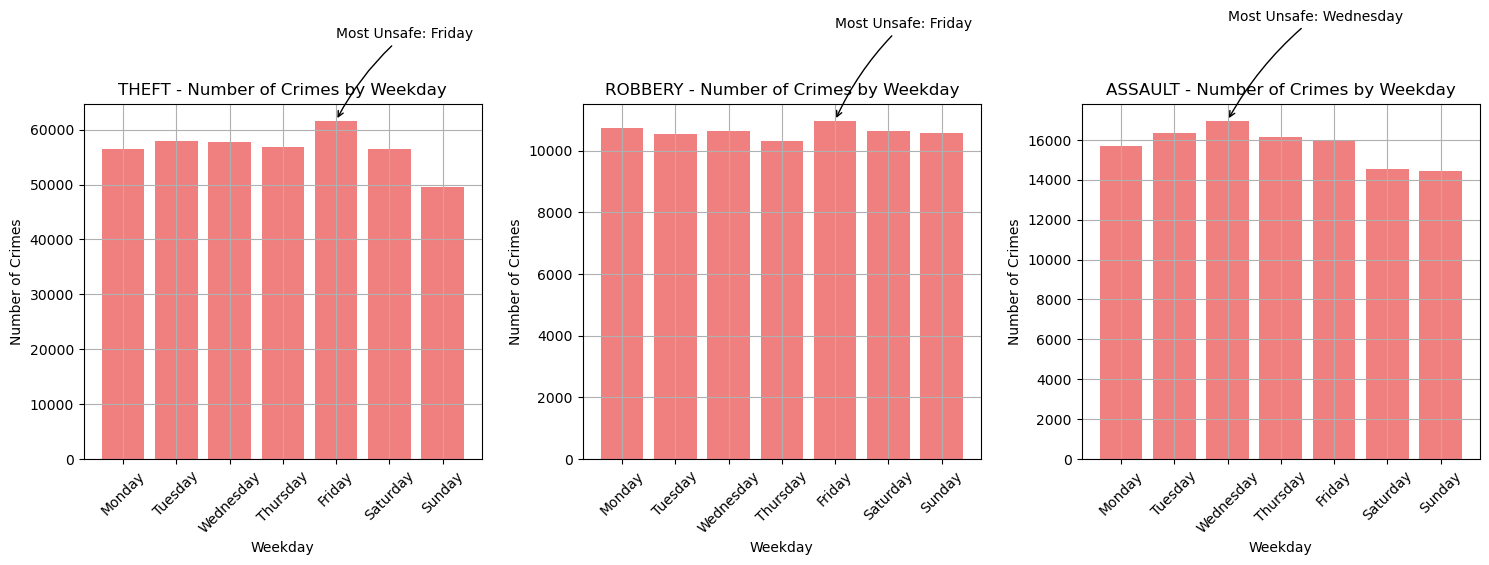

In [25]:
# Filter data for THEFT
theft_data = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Primary Type"] == "THEFT"]

# Filter data for ROBBERY
robbery_data = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Primary Type"] == "ROBBERY"]

# Filter data for ASSAULT
assault_data = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Primary Type"] == "ASSAULT"]

# Extract weekday for each crime type
theft_data["Weekday"] = theft_data["Date"].dt.weekday
robbery_data["Weekday"] = robbery_data["Date"].dt.weekday
assault_data["Weekday"] = assault_data["Date"].dt.weekday

# Group data by weekday for each crime type
theft_by_weekday = theft_data.groupby("Weekday").size().reset_index(name="Number of Crimes")
robbery_by_weekday = robbery_data.groupby("Weekday").size().reset_index(name="Number of Crimes")
assault_by_weekday = assault_data.groupby("Weekday").size().reset_index(name="Number of Crimes")

# Define weekday names for better readability
weekday_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Create a bar plot to visualize the number of crimes on each weekday for THEFT
plt.figure(figsize=(15, 6))
plt.subplot(131)
plt.bar(weekday_names, theft_by_weekday["Number of Crimes"], color="lightcoral")
plt.title("THEFT - Number of Crimes by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.grid(True)

# Create a bar plot to visualize the number of crimes on each weekday for ROBBERY
plt.subplot(132)
plt.bar(weekday_names, robbery_by_weekday["Number of Crimes"], color="lightcoral")
plt.title("ROBBERY - Number of Crimes by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.grid(True)

# Create a bar plot to visualize the number of crimes on each weekday for ASSAULT
plt.subplot(133)
plt.bar(weekday_names, assault_by_weekday["Number of Crimes"], color="lightcoral")
plt.title("ASSAULT - Number of Crimes by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.grid(True)

# Annotate the plots with the most unsafe weekdays for each crime type
most_unsafe_weekday_theft = theft_by_weekday[theft_by_weekday["Number of Crimes"] == theft_by_weekday["Number of Crimes"].max()]
most_unsafe_weekday_robbery = robbery_by_weekday[robbery_by_weekday["Number of Crimes"] == robbery_by_weekday["Number of Crimes"].max()]
most_unsafe_weekday_assault = assault_by_weekday[assault_by_weekday["Number of Crimes"] == assault_by_weekday["Number of Crimes"].max()]


plt.subplot(131)
plt.annotate(f"Most Unsafe: {weekday_names[most_unsafe_weekday_theft['Weekday'].values[0]]}", 
             xy=(most_unsafe_weekday_theft["Weekday"].values[0], most_unsafe_weekday_theft["Number of Crimes"].values[0]), 
             xytext=(most_unsafe_weekday_theft["Weekday"].values[0], most_unsafe_weekday_theft["Number of Crimes"].values[0] + 15000),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.1"))

plt.subplot(132)
plt.annotate(f"Most Unsafe: {weekday_names[most_unsafe_weekday_robbery['Weekday'].values[0]]}", 
             xy=(most_unsafe_weekday_robbery["Weekday"].values[0], most_unsafe_weekday_robbery["Number of Crimes"].values[0]), 
             xytext=(most_unsafe_weekday_robbery["Weekday"].values[0], most_unsafe_weekday_robbery["Number of Crimes"].values[0] + 3000),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.1"))

plt.subplot(133)
plt.annotate(f"Most Unsafe: {weekday_names[most_unsafe_weekday_assault['Weekday'].values[0]]}", 
             xy=(most_unsafe_weekday_assault["Weekday"].values[0], most_unsafe_weekday_assault["Number of Crimes"].values[0]), 
             xytext=(most_unsafe_weekday_assault["Weekday"].values[0], most_unsafe_weekday_assault["Number of Crimes"].values[0] + 5000),
             arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.1"))

plt.tight_layout()
plt.show()


Which are the worst 10 dates (most recorded crimes) of 2008? Does this trend hold for the other years?


Top 10 dates with the most recorded crimes in 2008:
                  Date  Number of Crimes
1  2008-01-01 00:01:00               303
2  2008-01-01 00:00:00               179
3  2008-01-01 09:00:00               127
4  2008-09-01 00:00:00                84
5  2008-01-01 12:00:00                83
6  2008-10-01 00:00:00                76
7  2008-07-01 00:00:00                72
8  2008-03-01 00:01:00                71
9  2008-08-01 00:00:00                68
10 2008-06-01 00:00:00                67


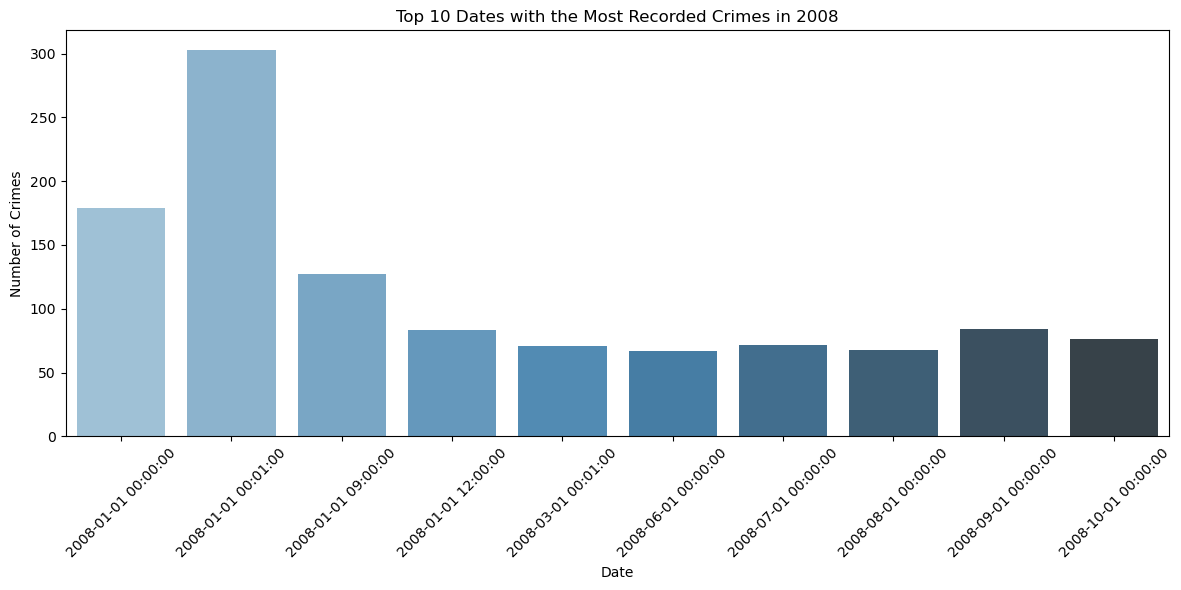


Top 10 dates with the most recorded crimes in 2009:
                  Date  Number of Crimes
1  2009-01-01 00:01:00               198
2  2009-01-01 00:00:00               169
3  2009-01-01 09:00:00               122
4  2009-01-01 12:00:00                86
5  2009-01-01 08:00:00                68
6  2009-08-01 00:01:00                68
7  2009-05-01 00:00:00                65
8  2009-10-01 12:00:00                65
9  2009-07-01 00:00:00                64
10 2009-06-01 00:00:00                60


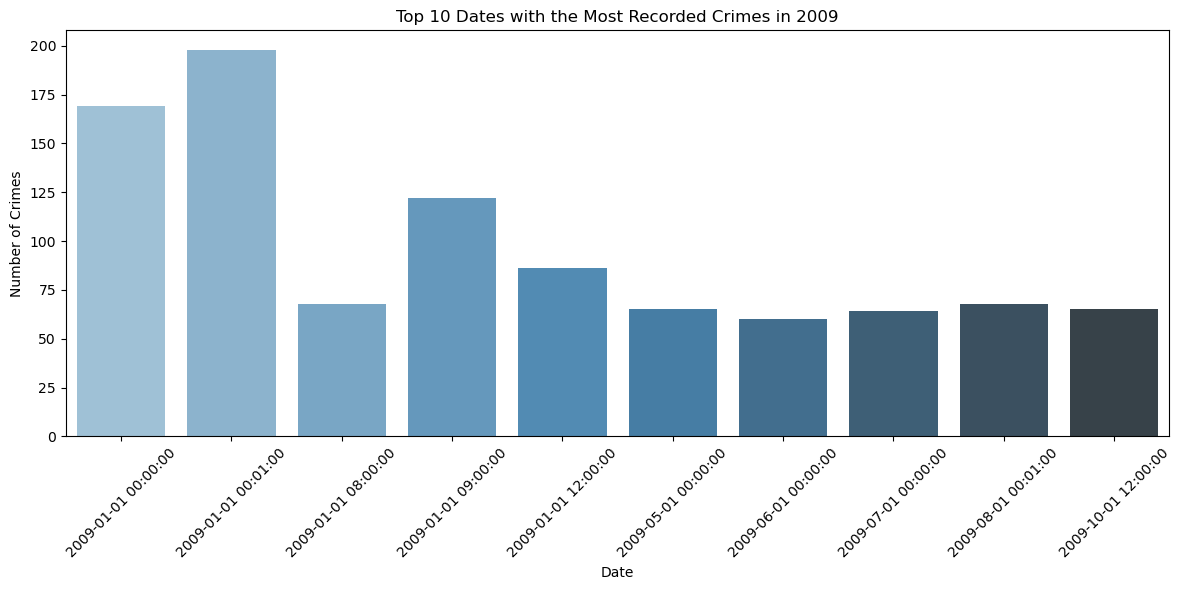


Top 10 dates with the most recorded crimes in 2010:
                  Date  Number of Crimes
1  2010-01-01 00:01:00               171
2  2010-01-01 00:00:00               156
3  2010-01-01 09:00:00                82
4  2010-03-01 09:00:00                63
5  2010-01-01 08:00:00                61
6  2010-05-01 00:01:00                61
7  2010-06-01 00:01:00                61
8  2010-04-01 09:00:00                61
9  2010-06-01 09:00:00                59
10 2010-01-01 12:00:00                58


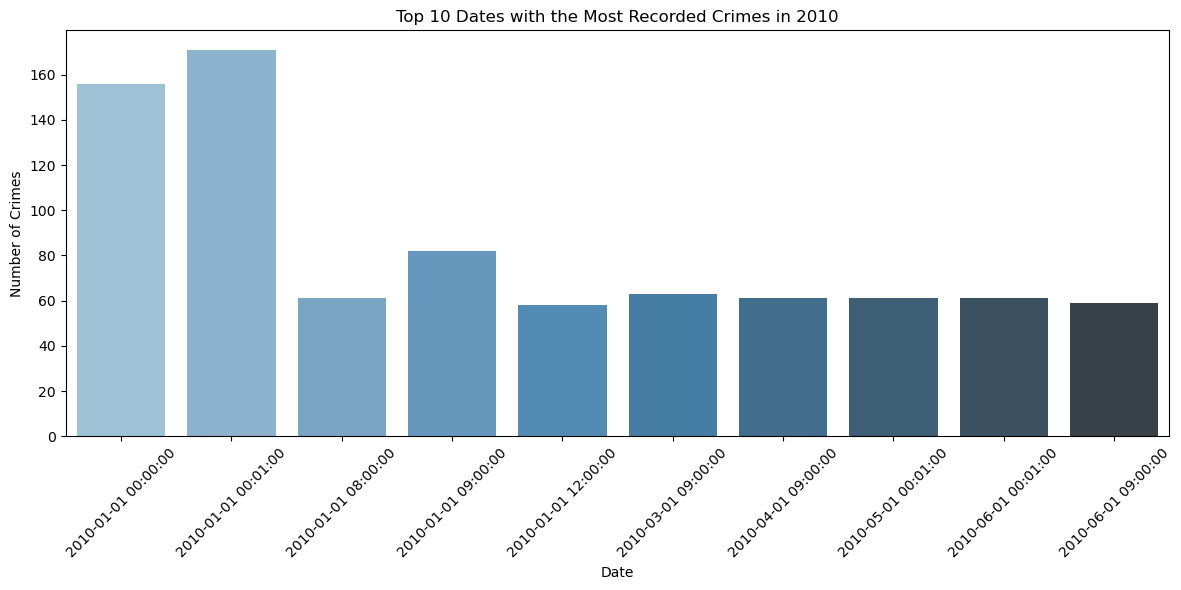


Top 10 dates with the most recorded crimes in 2011:
                  Date  Number of Crimes
1  2011-01-01 00:01:00               160
2  2011-01-01 00:00:00               142
3  2011-01-01 09:00:00                92
4  2011-09-01 09:00:00                70
5  2011-12-01 09:00:00                63
6  2011-01-01 08:00:00                60
7  2011-08-01 09:00:00                59
8  2011-04-01 09:00:00                59
9  2011-01-01 12:00:00                59
10 2011-03-01 09:00:00                57


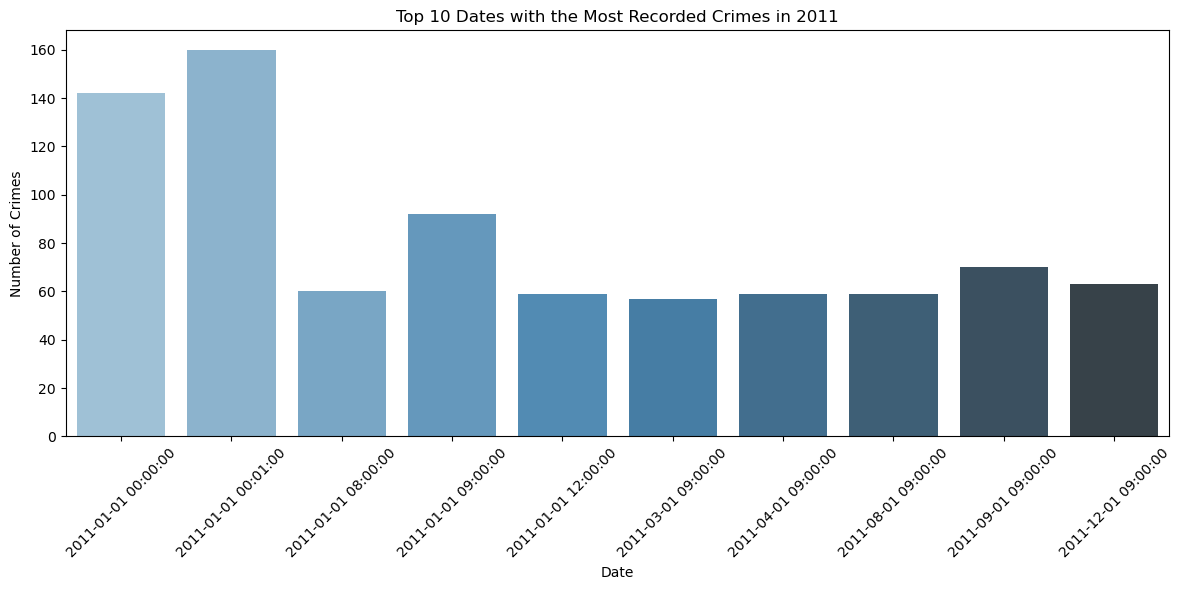


Top 10 dates with the most recorded crimes in 2012:
                  Date  Number of Crimes
1  2012-01-01 00:01:00               197
2  2012-01-01 00:00:00               146
3  2012-01-01 09:00:00                93
4  2012-03-01 09:00:00                74
5  2012-06-01 09:00:00                70
6  2012-10-01 09:00:00                64
7  2012-06-01 12:00:00                61
8  2012-08-01 09:00:00                61
9  2012-05-01 09:00:00                59
10 2012-09-01 09:00:00                59


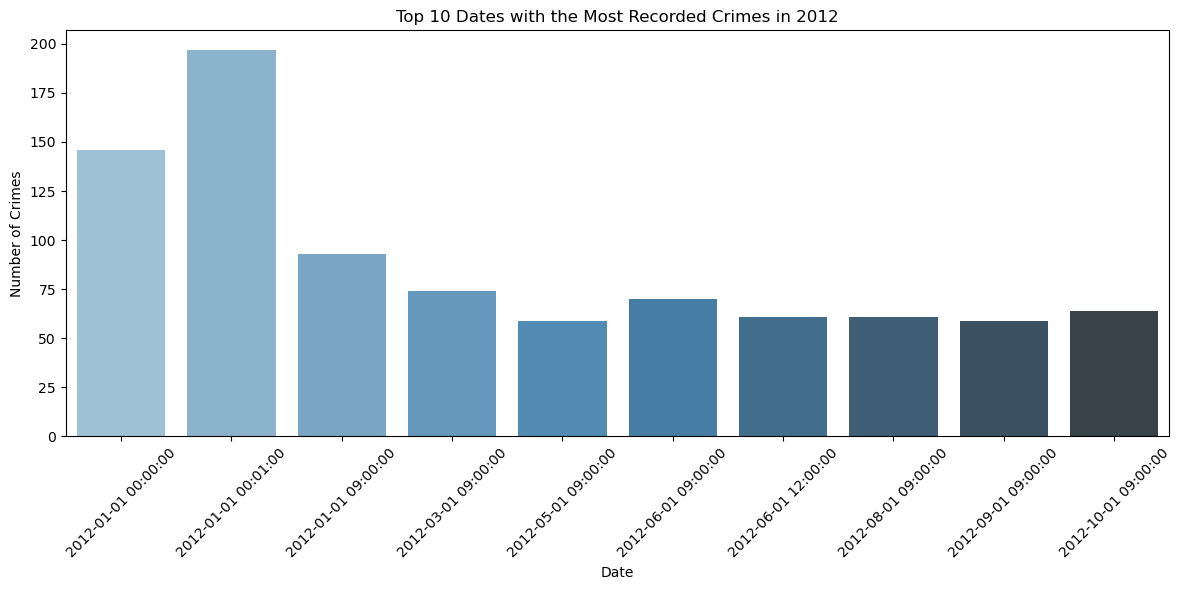

In [26]:
# Define a function to get the top 10 dates with the most recorded crimes for a given year
def get_top_10_dates(year):
    # Filter data for the specified year
    crime_data_year = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == year]

    # Group the data by date and count the number of recorded crimes for each date
    recorded_crimes_by_date_year = crime_data_year["Date"].value_counts().reset_index()
    recorded_crimes_by_date_year.columns = ["Date", "Number of Crimes"]

    # Sort the dates in descending order of the number of recorded crimes
    recorded_crimes_by_date_year = recorded_crimes_by_date_year.sort_values(by="Number of Crimes", ascending=False)

    # Set the index to start from 1
    recorded_crimes_by_date_year.index = range(1, len(recorded_crimes_by_date_year) + 1)

    # Convert "Date" column to datetime format
    recorded_crimes_by_date_year["Date"] = pd.to_datetime(recorded_crimes_by_date_year["Date"])

    # Select the top 10 dates with the most recorded crimes and sort them by date
    top_10_dates_year = recorded_crimes_by_date_year.head(10).sort_values(by="Date")

    return top_10_dates_year

def get_top_10_dates_to_print(year):
    # Filter data for the specified year
    crime_data_year = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == year]

    # Group the data by date and count the number of recorded crimes for each date
    recorded_crimes_by_date_year = crime_data_year["Date"].value_counts().reset_index()
    recorded_crimes_by_date_year.columns = ["Date", "Number of Crimes"]

    # Sort the dates in descending order of the number of recorded crimes
    recorded_crimes_by_date_year = recorded_crimes_by_date_year.sort_values(by="Number of Crimes", ascending=False)

    # Set the index to start from 1
    recorded_crimes_by_date_year.index = range(1, len(recorded_crimes_by_date_year) + 1)

    # Select the top 10 dates with the most recorded crimes
    top_10_dates_year = recorded_crimes_by_date_year.head(10)

    return top_10_dates_year


# Loop through multiple years and check if the trend holds
years_to_check = [2008, 2009, 2010, 2011, 2012] 

for year in years_to_check:
    # Get the top 10 dates for the current year
    top_10_dates_year = get_top_10_dates(year)

    top_10_dates_year_to_print = get_top_10_dates_to_print(year)

    # Print the Top 10 dates with the most recorded crimes for the current year with index starting from 1
    print(f"\nTop 10 dates with the most recorded crimes in {year}:")
    print(top_10_dates_year_to_print)


    # Plot the top 10 dates for the current year
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Date", y="Number of Crimes", data=top_10_dates_year, palette="Blues_d")
    plt.title(f"Top 10 Dates with the Most Recorded Crimes in {year}")
    plt.xlabel("Date")
    plt.ylabel("Number of Crimes")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


### Trend Analysis Across Other Years

**Examining the Consistency of the Trend:**

    * To determine the stability of the observed trend, we extended our analysis to other years. The findings indicate that the pattern remains consistent across various years.

**Key Observations:**

    * The most frequent time for crimes is consistently observed on the 1st of January at 00:01:00.
    * Following this peak, there is a noticeable decrease in the number of crimes reported in the subsequent hours.
    * This analysis suggests that the identified trend, with a peak in crimes at the beginning of the year followed by a decline, persists across multiple years.

From the perspective of total number of crime records, which are the Top 10 primary crime types? Which are the Bottom 10?

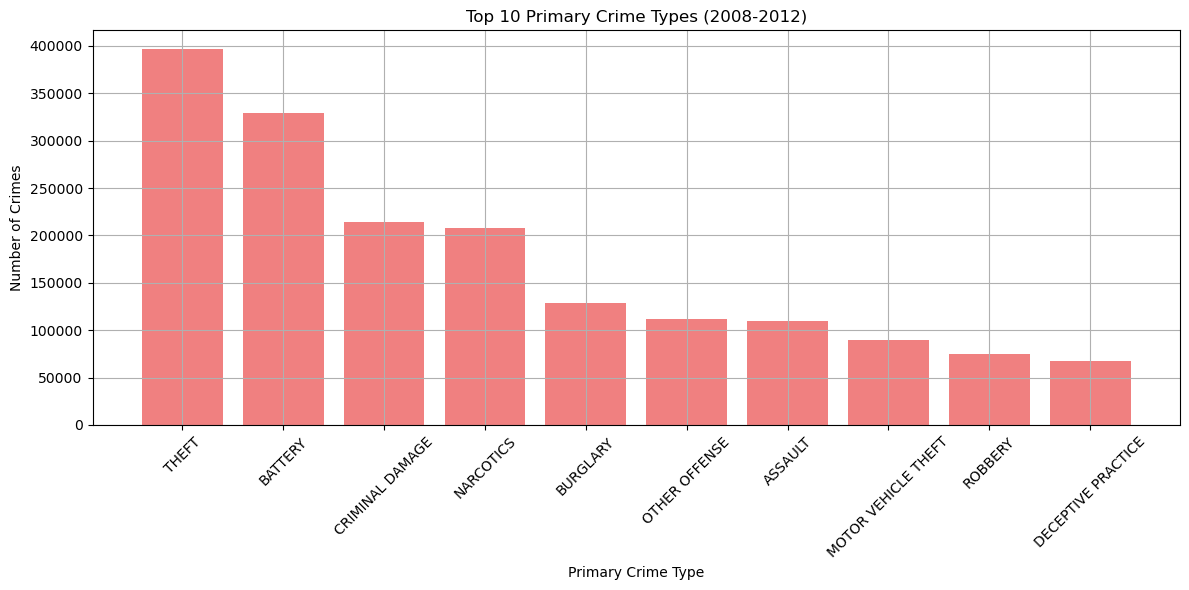

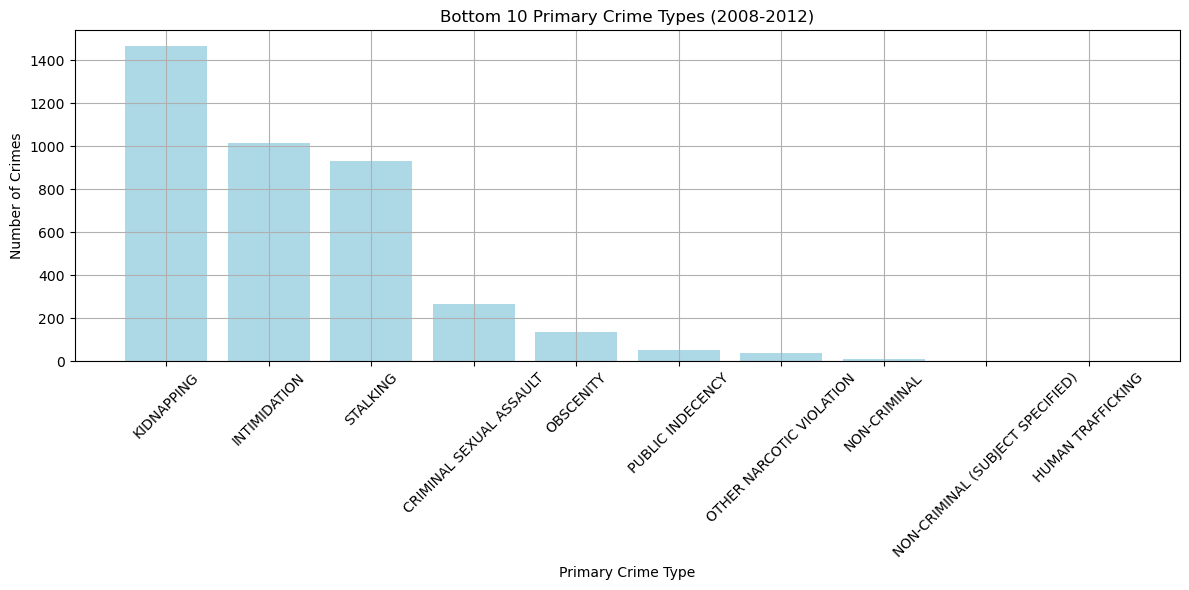

In [27]:
# Filter the DataFrame for the years 2008-2012
crime_data_2008_to_2012 = chicago_crime_2001_to_2023_df[
    (chicago_crime_2001_to_2023_df["Year"] >= 2008) & (chicago_crime_2001_to_2023_df["Year"] <= 2012)
]

# Group the data by "Primary Type" and count the number of records for each primary crime type
crime_records_by_type = crime_data_2008_to_2012["Primary Type"].value_counts().reset_index()
crime_records_by_type.columns = ["Primary Type", "Number of Crimes"]

# Sort the primary crime types by the number of recorded crimes in descending order
crime_records_by_type = crime_records_by_type.sort_values(by="Number of Crimes", ascending=False)

# Get the Top 10 and Bottom 10 primary crime types
top_10_crime_types = crime_records_by_type.head(10)
bottom_10_crime_types = crime_records_by_type.tail(10)

# Create a bar plot for the Top 10 primary crime types
plt.figure(figsize=(12, 6))
plt.bar(top_10_crime_types["Primary Type"], top_10_crime_types["Number of Crimes"], color="lightcoral")
plt.title("Top 10 Primary Crime Types (2008-2012)")
plt.xlabel("Primary Crime Type")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.grid(True)


plt.tight_layout()
plt.show()

# Create a bar plot for the Bottom 10 primary crime types
plt.figure(figsize=(12, 6))
plt.bar(bottom_10_crime_types["Primary Type"], bottom_10_crime_types["Number of Crimes"], color="lightblue")
plt.title("Bottom 10 Primary Crime Types (2008-2012)")
plt.xlabel("Primary Crime Type")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.grid(True)


plt.tight_layout()
plt.show()


For all those crime categories we identified, how does their distribution instead look per year - rather than the full 2008-2012 period as a whole?


Top 10 crime types in 2008:
           Primary Type  Number of Crimes
1                 THEFT             88437
2               BATTERY             75930
3       CRIMINAL DAMAGE             52843
4             NARCOTICS             46506
5         OTHER OFFENSE             26532
6              BURGLARY             26218
7               ASSAULT             25448
8   MOTOR VEHICLE THEFT             18881
9               ROBBERY             16703
10   DECEPTIVE PRACTICE             14933


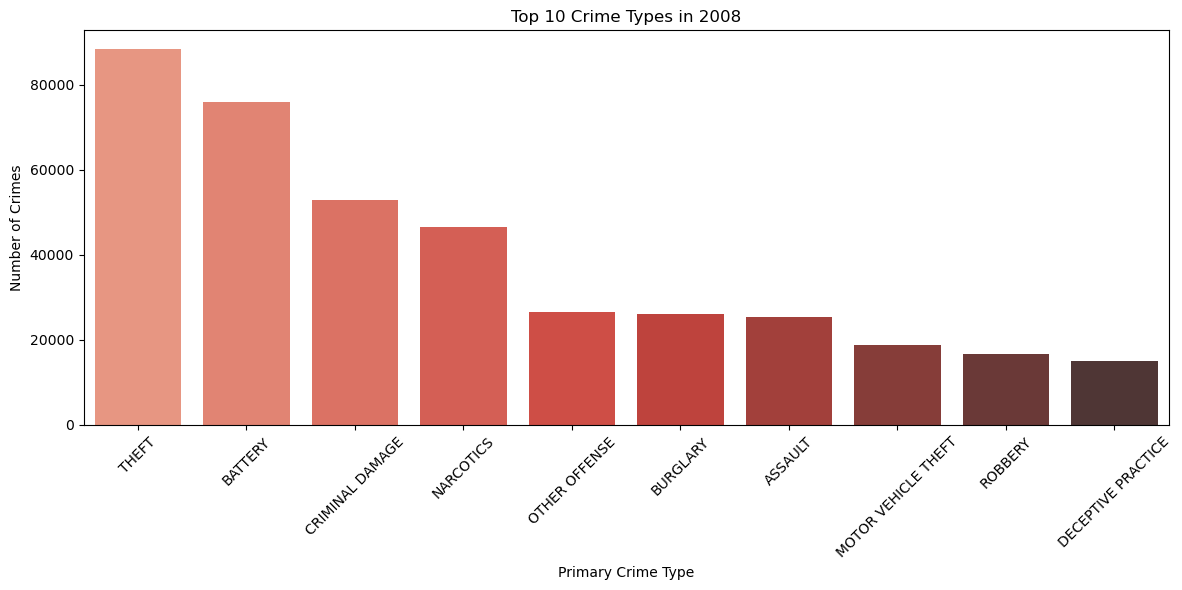


Top 10 crime types in 2009:
           Primary Type  Number of Crimes
1                 THEFT             80976
2               BATTERY             68460
3       CRIMINAL DAMAGE             47725
4             NARCOTICS             43542
5              BURGLARY             26767
6         OTHER OFFENSE             25601
7               ASSAULT             22861
8               ROBBERY             15981
9   MOTOR VEHICLE THEFT             15482
10   DECEPTIVE PRACTICE             13878


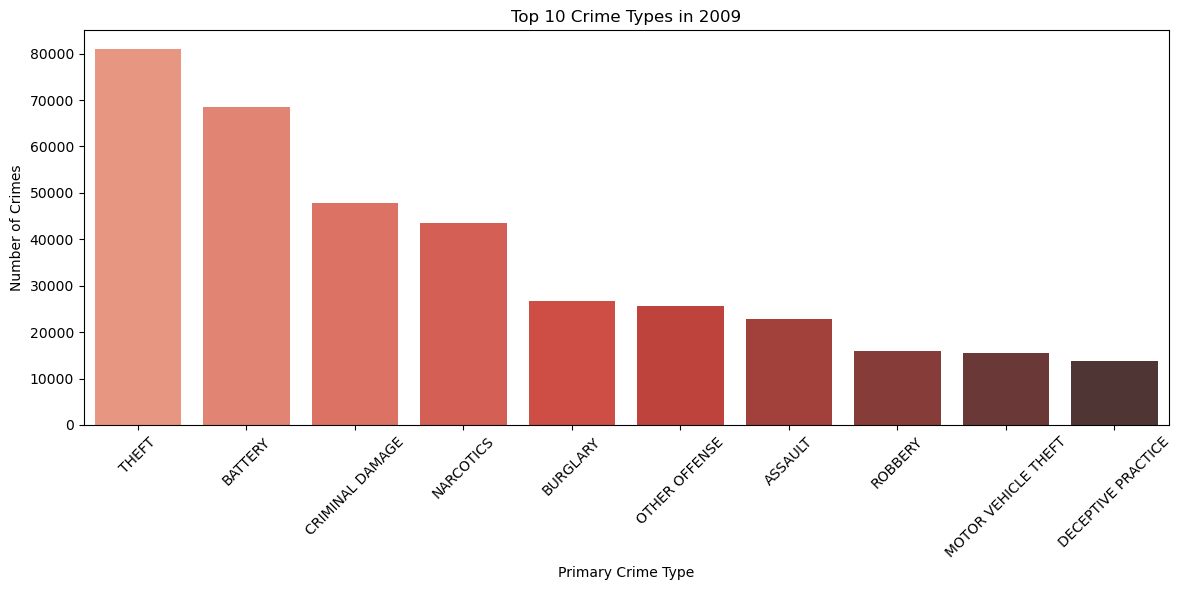


Top 10 crime types in 2010:
           Primary Type  Number of Crimes
1                 THEFT             76757
2               BATTERY             65401
3             NARCOTICS             43398
4       CRIMINAL DAMAGE             40654
5              BURGLARY             26422
6         OTHER OFFENSE             22012
7               ASSAULT             21537
8   MOTOR VEHICLE THEFT             19029
9               ROBBERY             14275
10   DECEPTIVE PRACTICE             12578


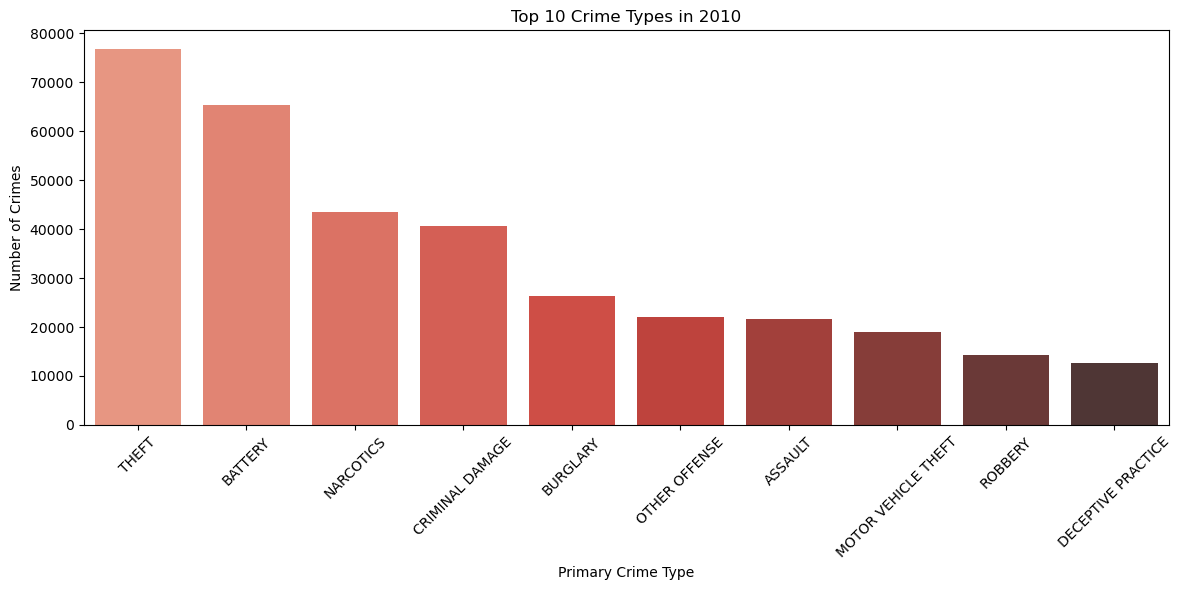


Top 10 crime types in 2011:
           Primary Type  Number of Crimes
1                 THEFT             75153
2               BATTERY             60459
3             NARCOTICS             38605
4       CRIMINAL DAMAGE             37331
5              BURGLARY             26620
6               ASSAULT             20411
7         OTHER OFFENSE             20206
8   MOTOR VEHICLE THEFT             19388
9               ROBBERY             13983
10   DECEPTIVE PRACTICE             12730


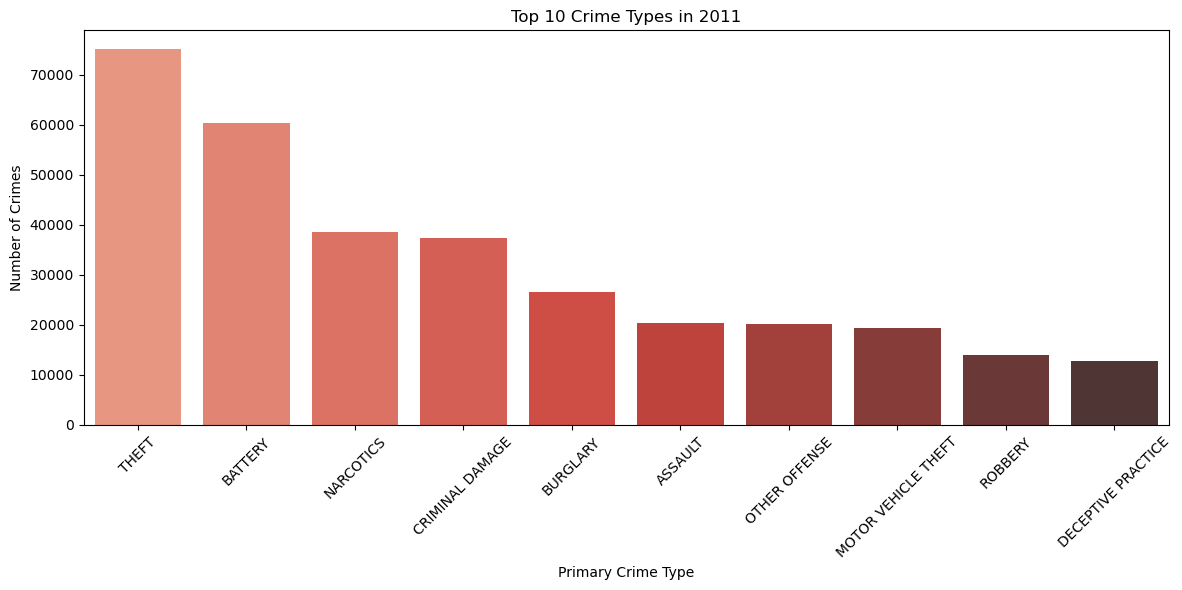


Top 10 crime types in 2012:
           Primary Type  Number of Crimes
1                 THEFT             75298
2               BATTERY             59016
3       CRIMINAL DAMAGE             35774
4             NARCOTICS             35444
5              BURGLARY             22776
6               ASSAULT             19861
7         OTHER OFFENSE             17489
8   MOTOR VEHICLE THEFT             16450
9    DECEPTIVE PRACTICE             13726
10              ROBBERY             13442


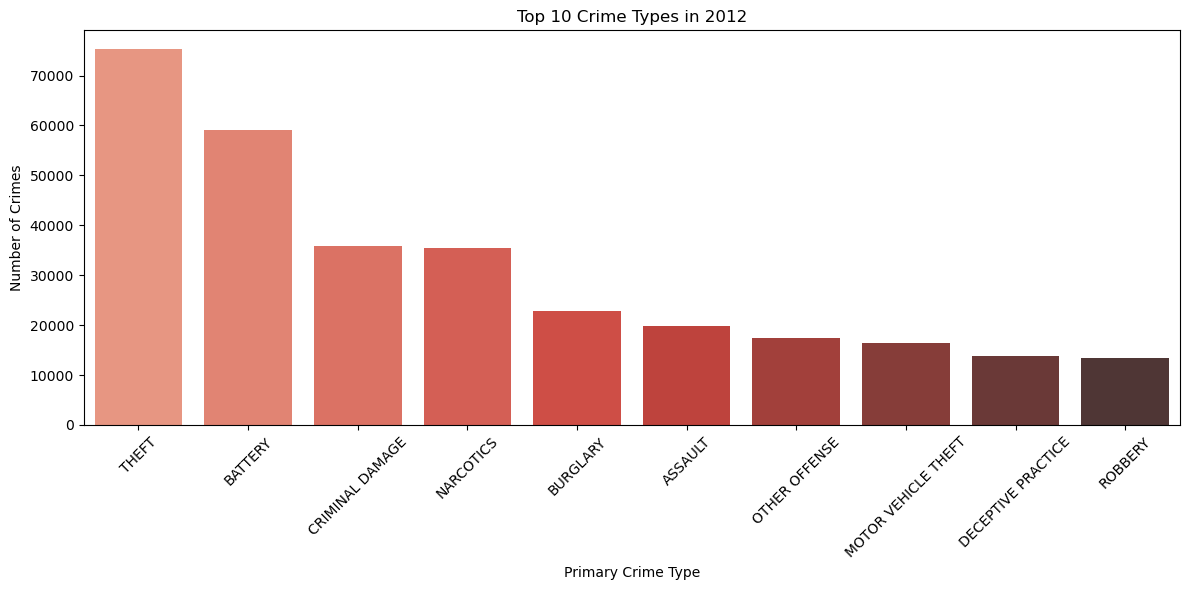

In [28]:
# Function to get the top 10 crime types for a given year
def get_top_10_crime_types(year):
    # Filter data for the specified year
    crime_data_year = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == year]

    # Group the data by "Primary Type" and count the number of crimes for each type
    crime_types_by_year = crime_data_year["Primary Type"].value_counts().reset_index()
    crime_types_by_year.columns = ["Primary Type", "Number of Crimes"]

    # Sort the crime types in descending order of the number of crimes
    crime_types_by_year = crime_types_by_year.sort_values(by="Number of Crimes", ascending=False)

    # Select the top 10 crime types
    top_10_crime_types = crime_types_by_year.head(10)

    return top_10_crime_types

def get_top_10_crime_types_to_print(year):
    # Filter data for the specified year
    crime_data_year = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == year]

    # Group the data by "Primary Type" and count the number of crimes for each type
    crime_types_by_year = crime_data_year["Primary Type"].value_counts().reset_index()
    crime_types_by_year.columns = ["Primary Type", "Number of Crimes"]

    # Sort the crime types in descending order of the number of crimes
    crime_types_by_year = crime_types_by_year.sort_values(by="Number of Crimes", ascending=False)

    # Set the index to start from 1
    crime_types_by_year.index = range(1, len(crime_types_by_year) + 1)

    # Select the top 10 crime types
    top_10_crime_types = crime_types_by_year.head(10)

    return top_10_crime_types


# Loop through multiple years and check if the trend holds
years_to_check = [2008, 2009, 2010, 2011, 2012]  

for year in years_to_check:
    # Get the top 10 crime types for the current year
    top_10_crime_types = get_top_10_crime_types(year)


    top_10_crime_types_to_print = get_top_10_crime_types_to_print(year)

    # Print the top 10 crime types for the current year
    print(f"\nTop 10 crime types in {year}:")
    print(top_10_crime_types_to_print)



    # Plot the top 10 crime types for the current year
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Primary Type", y="Number of Crimes", data=top_10_crime_types, palette="Reds_d")
    plt.title(f"Top 10 Crime Types in {year}")
    plt.xlabel("Primary Crime Type")
    plt.ylabel("Number of Crimes")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Which primary crime types does the city of Chicago seem to get better at preventing? For which ones is it the opposite, i.e, the situation is getting worse? 

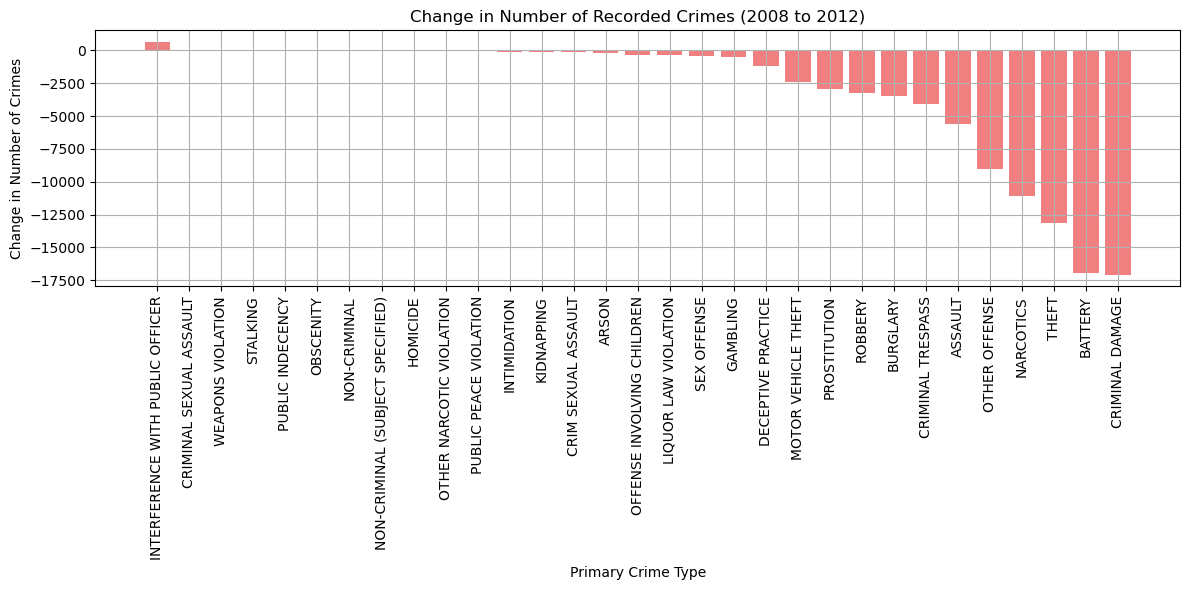

In [29]:
# Filter the DataFrame for the years 2008 and 2012
crime_data_2008 = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == 2008]
crime_data_2012 = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Year"] == 2012]

# Group the data by "Primary Type" and count the number of records for each year
crime_records_2008 = crime_data_2008["Primary Type"].value_counts().reset_index()
crime_records_2008.columns = ["Primary Type", "Number of Crimes (2008)"]

crime_records_2012 = crime_data_2012["Primary Type"].value_counts().reset_index()
crime_records_2012.columns = ["Primary Type", "Number of Crimes (2012)"]

# Merge the data for 2008 and 2012
crime_records_change = pd.merge(crime_records_2008, crime_records_2012, on="Primary Type", how="outer")

# Fill missing values with 0 (crime types that didn't exist in one of the years)
crime_records_change = crime_records_change.fillna(0)

# Calculate the change in the number of crimes
crime_records_change["Change"] = crime_records_change["Number of Crimes (2012)"] - crime_records_change["Number of Crimes (2008)"]

# Sort the crime types by change in descending order
crime_records_change = crime_records_change.sort_values(by="Change", ascending=False)

# Create a bar plot to visualize the change in the number of crimes
plt.figure(figsize=(12, 6))
plt.bar(crime_records_change["Primary Type"], crime_records_change["Change"], color="lightcoral")
plt.title("Change in Number of Recorded Crimes (2008 to 2012)")
plt.xlabel("Primary Crime Type")
plt.ylabel("Change in Number of Crimes")
plt.xticks(rotation=90)
plt.grid(True)


plt.tight_layout()
plt.show()


### Change in Number of Recorded Crimes (2008 to 2012)

#### Overview:

The analysis of recorded crimes from 2008 to 2012 reveals notable changes in various primary crime types. The following summary categorizes these changes:

**Increase in Number of Crimes:**

    * INTERFERENCE WITH PUBLIC OFFICER

**No Change in Number of Crimes for:**

    * CRIMINAL SEXUAL ASSAULT
    * WEAPONS VIOLATION
    * STALKING
    * PUBLIC INDECENCY
    * OBSCENITY
    * NON-CRIMINAL
    * NON-CRIMINAL (SUBJECT SPECIFIED)
    * HOMICIDE
    * OTHER NARCOTIC VIOLATION
    * PUBLIC PEACE VIOLATION

**Decrease in Number of Crimes for:**

    * INTIMIDATION
    * KIDNAPPING
    * CRIM SEXUAL ASSAULT
    * ARSON
    * OFFENSE INVOLVING CHILDREN
    * LIQUOR LAW VIOLATION
    * SEX OFFENSE
    * GAMBLING
    * DECEPTIVE PRACTICE
    * MOTOR VEHICLE THEFT
    * PROSTITUTION
    * ROBBERY
    * BURGLARY
    * CRIMINAL TRESPASS
    * ASSAULT
    * OTHER OFFENSE
    * NARCOTICS
    * THEFT
    * BATTERY
    * CRIMINAL DAMAGE

This comprehensive breakdown outlines the specific primary crime types that experienced an increase, no change, or a decrease in recorded incidents during the specified period.

# 6 - Night Stalker

Are there more or less crimes reported during daytime, compared with nighttime? Daytime is considered as all hours between 06:00-18:00, nighttime is the rest of the day.

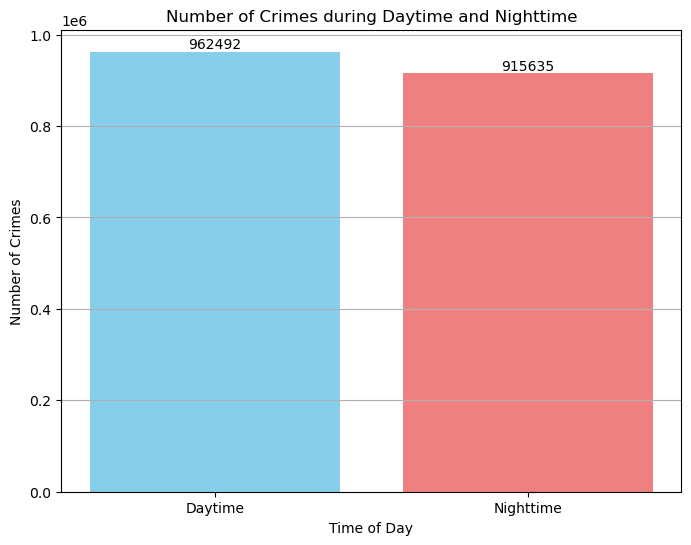

In [30]:
# Convert the "Date" column to datetime objects
chicago_crime_2001_to_2023_df["Date"] = pd.to_datetime(chicago_crime_2001_to_2023_df["Date"])

# Define the time boundaries for daytime and nighttime
daytime_start = 6
daytime_end = 18

# Create a new column "Time of Day" to categorize records as daytime or nighttime
chicago_crime_2001_to_2023_df["Time of Day"] = (
    chicago_crime_2001_to_2023_df["Date"].dt.hour
)

# Define a function to categorize records as daytime or nighttime
def categorize_time_of_day(hour):
    if daytime_start <= hour < daytime_end:
        return "Daytime"
    else:
        return "Nighttime"

# Apply the categorization function to the "Time of Day" column
chicago_crime_2001_to_2023_df["Time of Day"] = chicago_crime_2001_to_2023_df["Time of Day"].apply(categorize_time_of_day)

# Count the number of crimes for each time category
crime_counts_by_time = chicago_crime_2001_to_2023_df["Time of Day"].value_counts()

# Create a bar plot to visualize the number of crimes during daytime and nighttime
plt.figure(figsize=(8, 6))
plt.bar(crime_counts_by_time.index, crime_counts_by_time.values, color=["skyblue", "lightcoral"])
plt.title("Number of Crimes during Daytime and Nighttime")
plt.xlabel("Time of Day")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=0)

# Annotate the bars with the exact numbers
for index, value in enumerate(crime_counts_by_time.values):
    # adds a text annotation to each bar in the bar plot, displaying the exact numerical value of the crime count at the top of the bar. The ha and va parameters control the alignment of the text relative to the specified coordinates.

    # ha="center": Horizontal alignment. The text is centered horizontally at the specified

    # va="bottom": Vertical alignment. The text is aligned at the bottom vertically.
    plt.text(index, value, str(value), ha="center", va="bottom")


# adds gridlines to the plot. Specifically, axis="y"
plt.grid(axis="y")
plt.show()


In general, for each weekday, how many crimes are recorded during daytime and how many during nighttime? What are the trends? Are there any weekdays that stands out somehow?

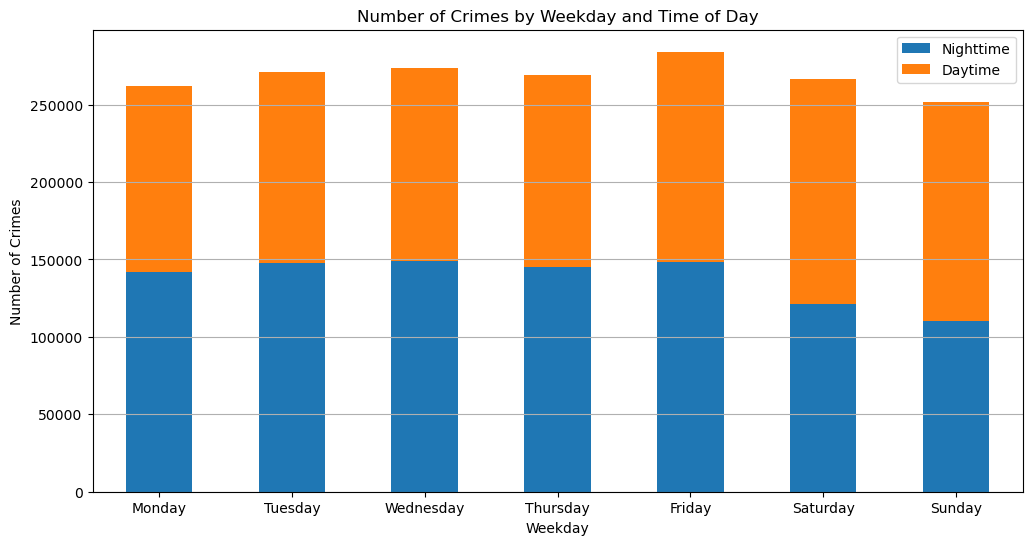

In [31]:
# Convert the "Date" column to datetime objects
chicago_crime_2001_to_2023_df["Date"] = pd.to_datetime(chicago_crime_2001_to_2023_df["Date"])

# Define the time boundaries for daytime and nighttime
daytime_start = 6
daytime_end = 18

# Create a new column "Time of Day" to categorize records as daytime or nighttime
chicago_crime_2001_to_2023_df["Time of Day"] = (
    chicago_crime_2001_to_2023_df["Date"].dt.hour
)

# Define a function to categorize records as daytime or nighttime
def categorize_time_of_day(hour):
    if daytime_start <= hour < daytime_end:
        return "Daytime"
    else:
        return "Nighttime"

# Apply the categorization function to the "Time of Day" column
chicago_crime_2001_to_2023_df["Time of Day"] = chicago_crime_2001_to_2023_df["Time of Day"].apply(categorize_time_of_day)

# Group the data by weekday and time of day and count the number of records for each group
crime_records_by_weekday_time = chicago_crime_2001_to_2023_df.groupby([chicago_crime_2001_to_2023_df["Date"].dt.dayofweek, "Time of Day"]).size().unstack().fillna(0)

# Define a list of weekday names for labeling
weekday_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Set the order of days in the week (starting from Monday)
order = [0, 1, 2, 3, 4, 5, 6]

# Reorder the days in the DataFrame
crime_records_by_weekday_time = crime_records_by_weekday_time.loc[order]

# Create a stacked bar plot to visualize the number of crimes for each weekday and time of day
crime_records_by_weekday_time.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Number of Crimes by Weekday and Time of Day")
plt.xlabel("Weekday")
plt.ylabel("Number of Crimes")
plt.xticks(range(7), weekday_names, rotation=0)
plt.legend(["Nighttime", "Daytime"], loc="upper right")


plt.grid(axis="y")
plt.show()


Analysis Summary:

* A noticeable trend is observed in the number of crimes, with slight variations, during both daytime and nighttime.
* Fridays stand out as the day with the highest reported crimes during the daytime.
* Throughout the week, the overall number of crimes remains relatively consistent between daytime and nighttime.
* Notably, there is a consistent trend of more crimes occurring during the daytime compared to nighttime throughout the entire week.

Does the trends we've found also hold if we look at each year individually?

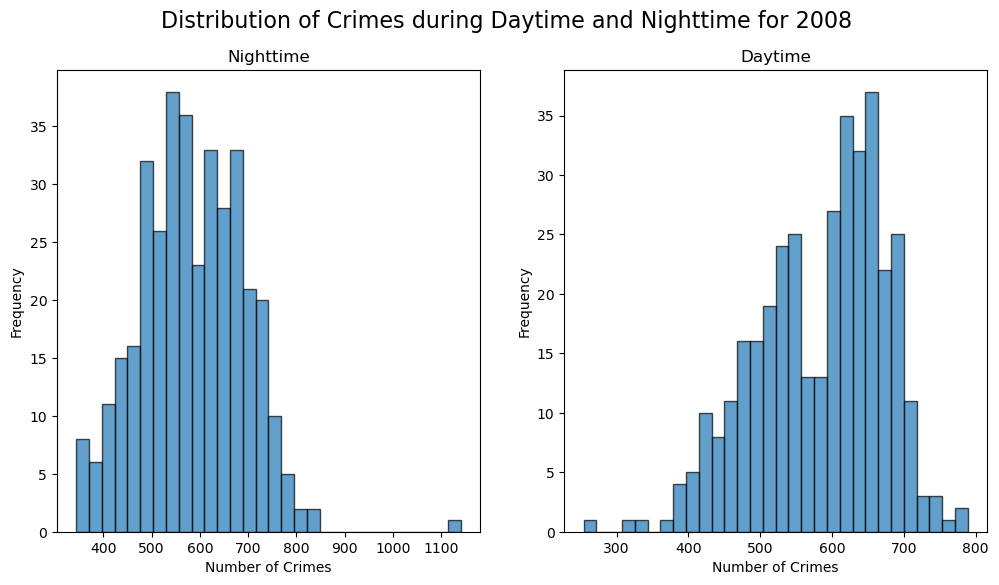

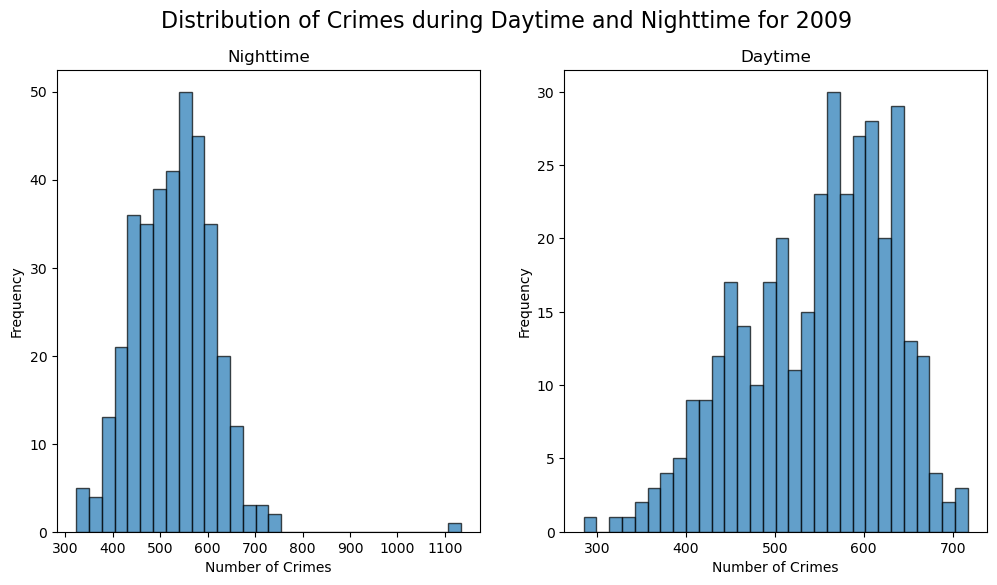

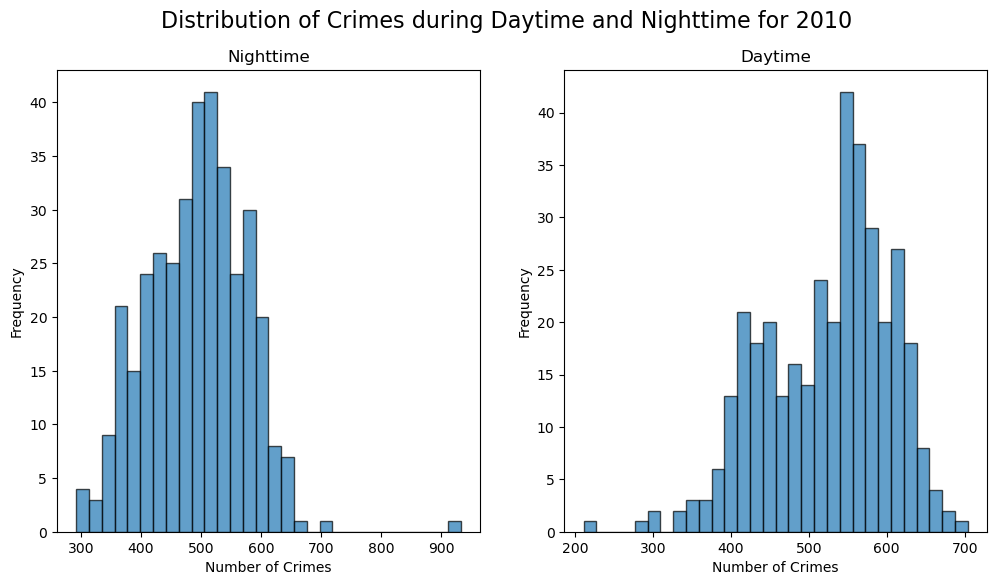

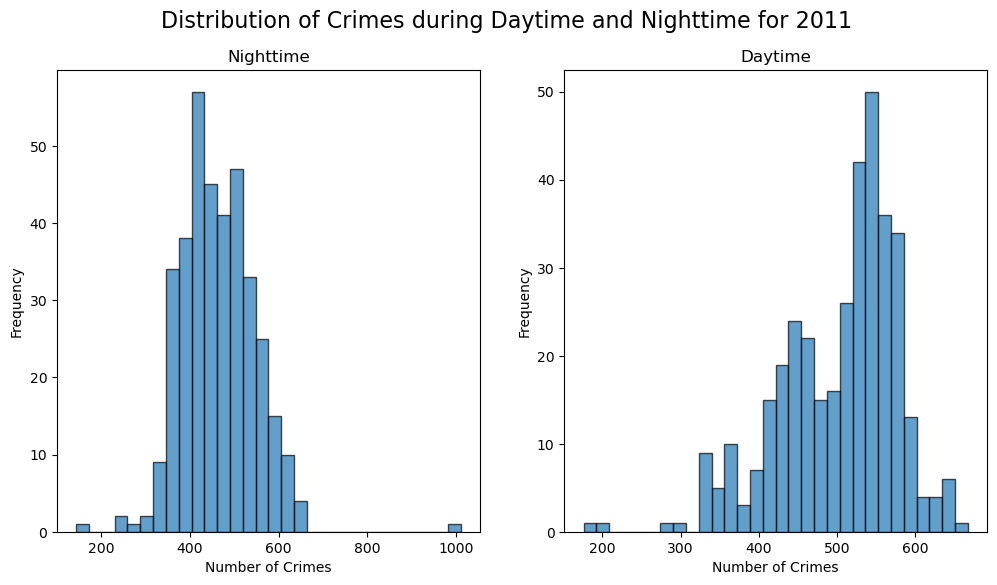

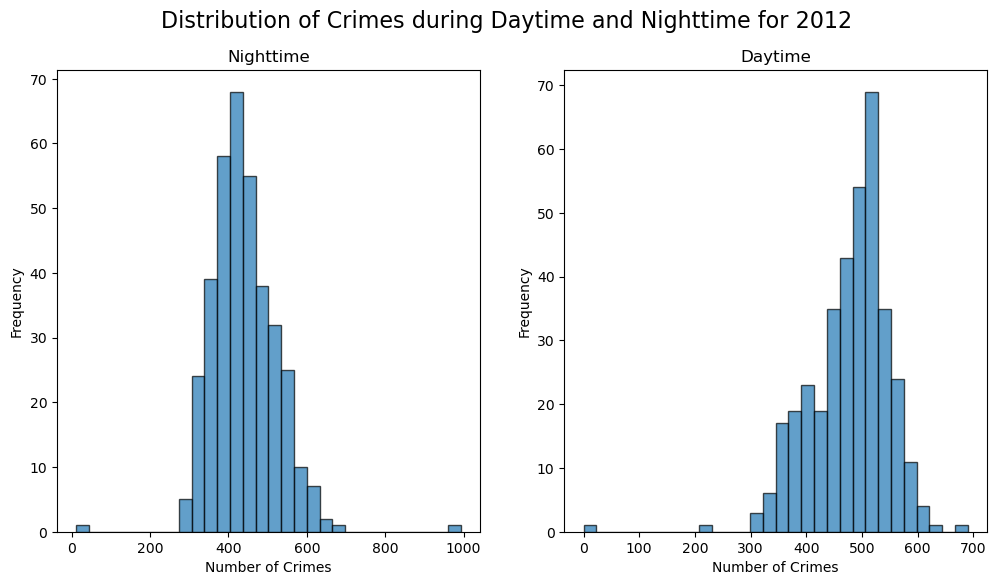

In [32]:
# Define the time boundaries for daytime and nighttime
daytime_start = 6
daytime_end = 18

# Create a new column "Time of Day" to categorize records as daytime or nighttime
chicago_crime_2001_to_2023_df["Time of Day"] = chicago_crime_2001_to_2023_df["Date"].dt.hour

# Define a function to categorize records as daytime or nighttime
def categorize_time_of_day(hour):
    if daytime_start <= hour < daytime_end:
        return "Daytime"
    else:
        return "Nighttime"

# Apply the categorization function to the "Time of Day" column
chicago_crime_2001_to_2023_df["Time of Day"] = chicago_crime_2001_to_2023_df["Time of Day"].apply(categorize_time_of_day)

# Group the data by year, weekday, and time of day, and count the number of records for each group

# pivot_table(...): This function is used to create a pivot table from the original DataFrame.

# index="Date": This specifies that the "Date" column should be used as the index of the pivot table, meaning each row in the pivot table corresponds to a unique date.

# columns="Time of Day": This specifies that the "Time of Day" column should be used to create columns in the pivot table, separating the data into different time of day categories.

# aggfunc="size": This specifies that the aggregation function used to fill the pivot table should be the size (count) of each group. In other words, it counts the number of occurrences for each combination of date and time of day.

# fill_value=0: This parameter specifies that missing values (if any) in the pivot table should be filled with zeros.

crime_records_by_year_weekday = chicago_crime_2001_to_2023_df.pivot_table(index="Date", columns="Time of Day", aggfunc="size", fill_value=0)

# Resample the data to have daily counts and calculate the rolling mean to smooth the data

# .resample("D"): This is a Pandas method for resampling time-series data. The argument "D" stands for daily frequency. The resampling operation groups the data by the specified frequency, which, in this case, is days.

# .sum(): After grouping the data by day, the .sum() method is applied to calculate the sum of crime records for each day. This operation consolidates the counts into a daily frequency, providing a new DataFrame (daily_counts) with the total number of crimes for each day.

# In summary, the line is transforming the original data, which may have irregular timestamps, into a new DataFrame (daily_counts) with a regular daily frequency, and the values represent the total number of crimes that occurred on each day. This can be useful for analyzing trends and patterns in crime occurrence at a daily level.

daily_counts = crime_records_by_year_weekday.resample("D").sum()

# Set custom x-axis ticks for years 2008 to 2012
years = range(2008, 2013)

# Create separate histograms for each year
for year in years:
    # Filter the data for the current year
    year_data = daily_counts[daily_counts.index.year == year]
    
    # Create subplots for Daytime and Nighttime histograms
    plt.figure(figsize=(12, 6))
    plt.suptitle(f"Distribution of Crimes during Daytime and Nighttime for {year}", fontsize=16)
    
    for i, time_of_day in enumerate(["Nighttime", "Daytime"]):
        plt.subplot(1, 2, i + 1)
        plt.hist(year_data[time_of_day], bins=30, edgecolor="k", alpha=0.7)
        plt.title(time_of_day)
        plt.xlabel("Number of Crimes")
        plt.ylabel("Frequency")
    
    plt.show()


Analysis Summary:

* The observed trend appears consistent across different years.
* Upon closer examination of each year individually, there are no significant variations in the number of crimes between daytime and nighttime.

Are there any weekdays in which Stalking occurs more often during nighttime?

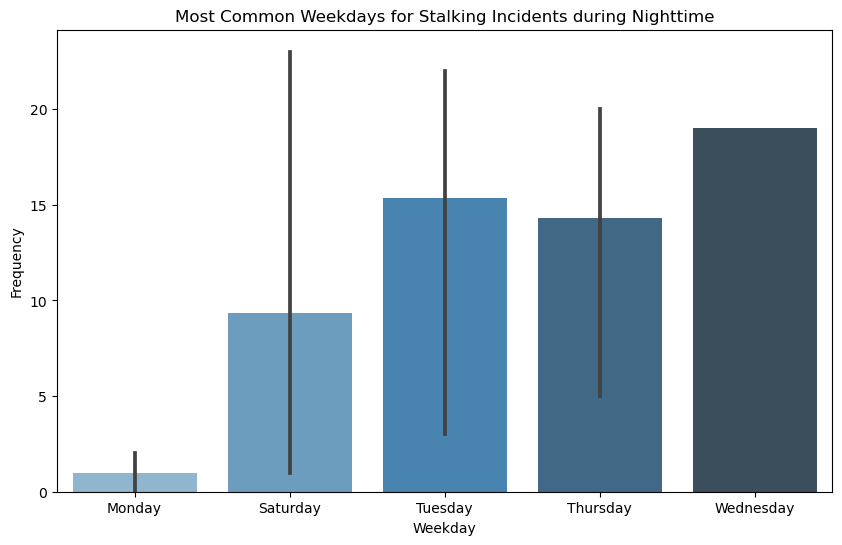

In [33]:
# Convert the "Date" column to datetime objects
chicago_crime_2001_to_2023_df["Date"] = pd.to_datetime(chicago_crime_2001_to_2023_df["Date"])

# Define the time boundaries for daytime and nighttime
daytime_start = 6
daytime_end = 18

# Create a new column "Time of Day" to categorize records as daytime or nighttime
chicago_crime_2001_to_2023_df["Time of Day"] = chicago_crime_2001_to_2023_df["Date"].dt.hour

# Define a function to categorize records as daytime or nighttime
def categorize_time_of_day(hour):
    if daytime_start <= hour < daytime_end:
        return "Daytime"
    else:
        return "Nighttime"

# Apply the categorization function to the "Time of Day" column
chicago_crime_2001_to_2023_df["Time of Day"] = chicago_crime_2001_to_2023_df["Time of Day"].apply(categorize_time_of_day)

# Filter the data for Stalking incidents during nighttime
stalking_data = chicago_crime_2001_to_2023_df[
    (chicago_crime_2001_to_2023_df["Primary Type"] == "STALKING") &
    (chicago_crime_2001_to_2023_df["Time of Day"] == "Nighttime")
]

# Extract the day of the week and hour
stalking_data["Day_of_Week"] = stalking_data["Date"].dt.day_name()
stalking_data["Hour"] = stalking_data["Date"].dt.hour

# Group the data by weekday and hour
stalking_by_day_hour = stalking_data.groupby(["Day_of_Week", "Hour"]).size().unstack(fill_value=0)

# Identify the weekdays with the highest frequency during nighttime
most_common_weekdays = stalking_by_day_hour.idxmax(axis=0)

# Create a bar plot with weekdays on the x-axis and frequency on the y-axis
plt.figure(figsize=(10, 6))
sns.barplot(x=most_common_weekdays.values, y=most_common_weekdays.index, palette="Blues_d")
plt.title("Most Common Weekdays for Stalking Incidents during Nighttime")
plt.xlabel("Weekday")
plt.ylabel("Frequency")

plt.show()


Are there any specific primary crime types that most often occur during nights? If so, which ones are they? Where do they occur? Are certain days of the week notable here somehow?

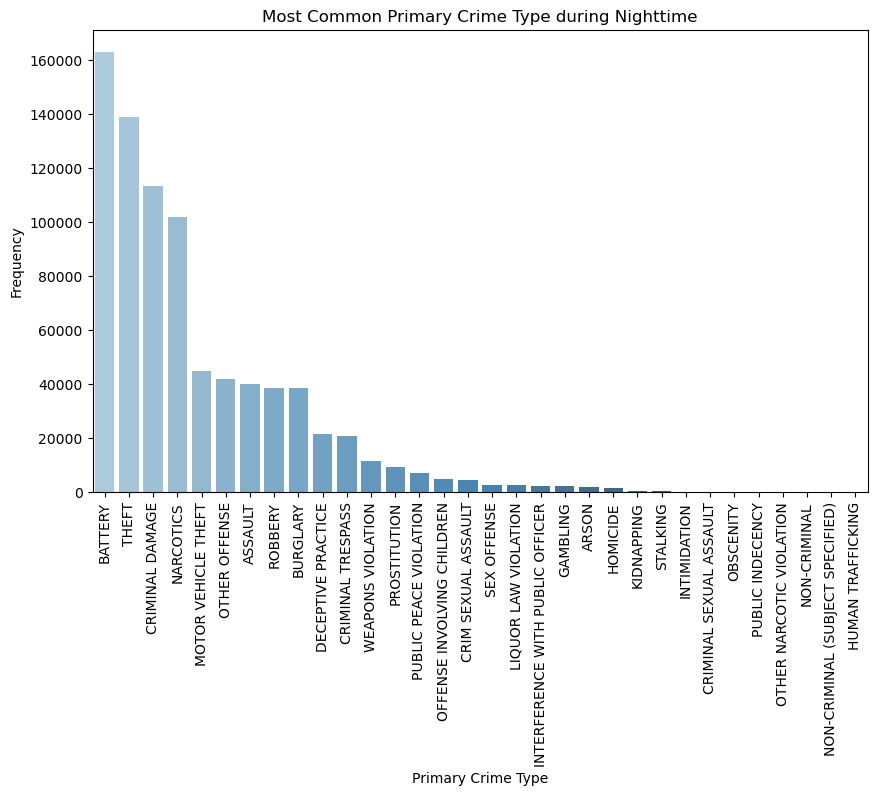

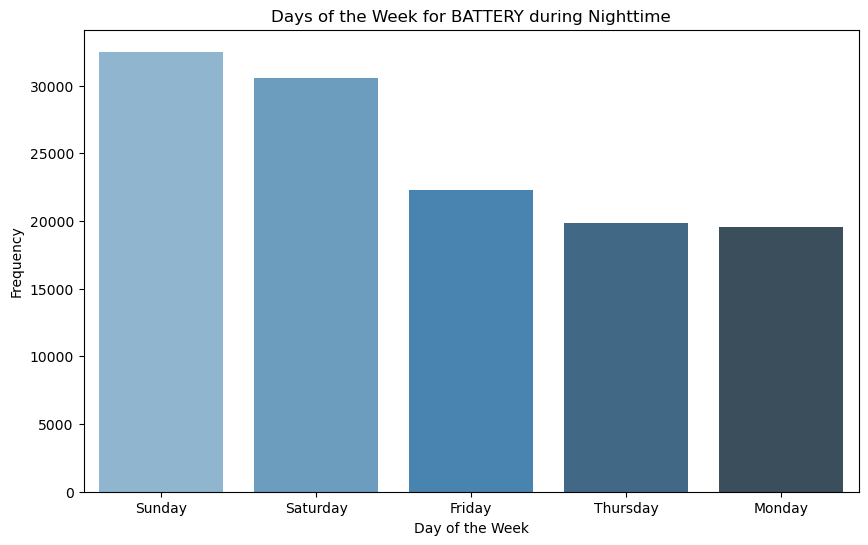

In [34]:
# Define the time boundaries for daytime and nighttime
daytime_start = 6
daytime_end = 18

# Filter data for nighttime incidents
nighttime_data = chicago_crime_2001_to_2023_df[
    ~chicago_crime_2001_to_2023_df["Date"].dt.hour.between(daytime_start, daytime_end)
]

# Group by Primary Type and count the occurrences
nighttime_crime_types = nighttime_data["Primary Type"].value_counts()

# Identify the most common primary crime type during nighttime
most_common_crime_type = nighttime_crime_types.idxmax()

# Create a bar plot for the most common primary crime type during nighttime
plt.figure(figsize=(10, 6))
sns.barplot(x=nighttime_crime_types.index, y=nighttime_crime_types.values, palette="Blues_d")
plt.title("Most Common Primary Crime Type during Nighttime")
plt.xlabel("Primary Crime Type")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

# Check if "Day_of_Week" column exists, and create it if not
if "Day_of_Week" not in nighttime_data.columns:
    nighttime_data["Day_of_Week"] = nighttime_data["Date"].dt.day_name()

# Create a plot for the days of the week
crime_weekdays = nighttime_data.groupby(["Primary Type", "Day_of_Week"]).size()
top_weekdays = crime_weekdays[most_common_crime_type].nlargest(5)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_weekdays.index, y=top_weekdays.values, palette="Blues_d")
plt.title("Days of the Week for " + most_common_crime_type + " during Nighttime")
plt.xlabel("Day of the Week")
plt.ylabel("Frequency")
plt.show()


Analysis Summary:

* The predominant primary crime type observed is "Battery."
* Notably, the peak occurrence of this crime type happens during nighttime.
* Specifically, the most common day of the week for this crime to occur during nighttime is Sundays.

# 7 - Grand Theft Auto

You just bought a new car. What weekday should you be most wary of as it has the highest risk for a Grand Theft Auto-style robbery (MOTOR VEHICLE THEFT)?

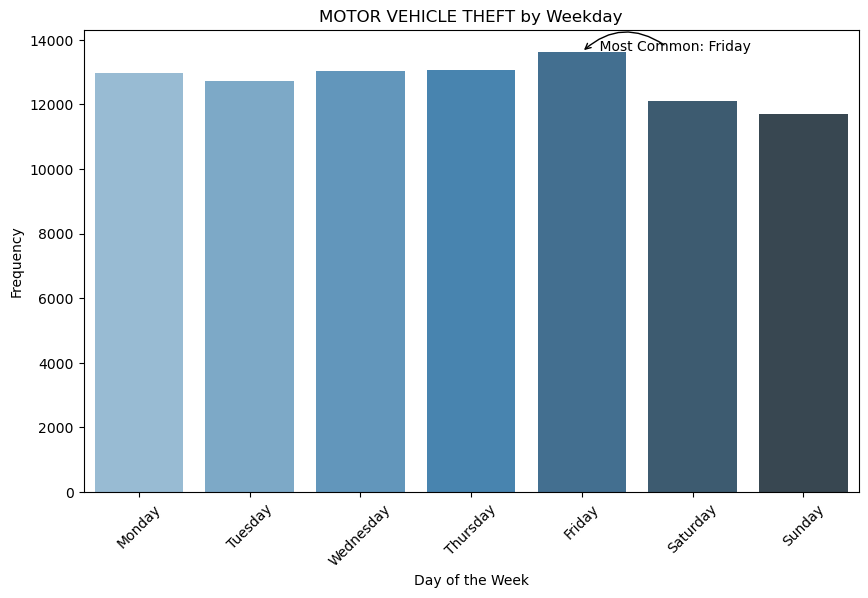

In [35]:
# Extract the day of the week from the "Date" column
chicago_crime_2001_to_2023_df["Day_of_Week"] = chicago_crime_2001_to_2023_df["Date"].dt.day_name()

# Filter data for MOTOR VEHICLE THEFT incidents
theft_data = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Primary Type"] == "MOTOR VEHICLE THEFT"]

# Define the order of weekdays
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Group by Day_of_Week and count the occurrences, and order the result by the custom weekday order
theft_by_weekday = theft_data["Day_of_Week"].value_counts().loc[weekday_order]

# Find the weekday with the highest occurrence

# .idxmax(): This method is applied to the Series, and it returns the index label associated with the maximum value in the Series. In other words, it gets the label corresponding to the day of the week with the highest frequency of "MOTOR VEHICLE THEFT."
most_common_weekday = theft_by_weekday.idxmax()

# Create a bar plot to visualize the occurrences of MOTOR VEHICLE THEFT by weekday
plt.figure(figsize=(10, 6))
sns.barplot(x=theft_by_weekday.index, y=theft_by_weekday.values, palette="Blues_d", order=weekday_order)
plt.title("MOTOR VEHICLE THEFT by Weekday")
plt.xlabel("Day of the Week")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

# Annotate the plot with the most common weekday

# get_loc(most_common_weekday): This method is used to get the integer location of the specified label (most_common_weekday) within the index. It returns the position of the label in the index.
plt.annotate(f"    Most Common: {most_common_weekday}", xy=(theft_by_weekday.index.get_loc(most_common_weekday), theft_by_weekday.max()),
             xytext=(theft_by_weekday.index.get_loc(most_common_weekday), theft_by_weekday.max() + 50),
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.4"))

plt.show()


For that day, where (at what location) should we absolutely avoid leave our cars carelessly? Where is it seemingly safest to do so?

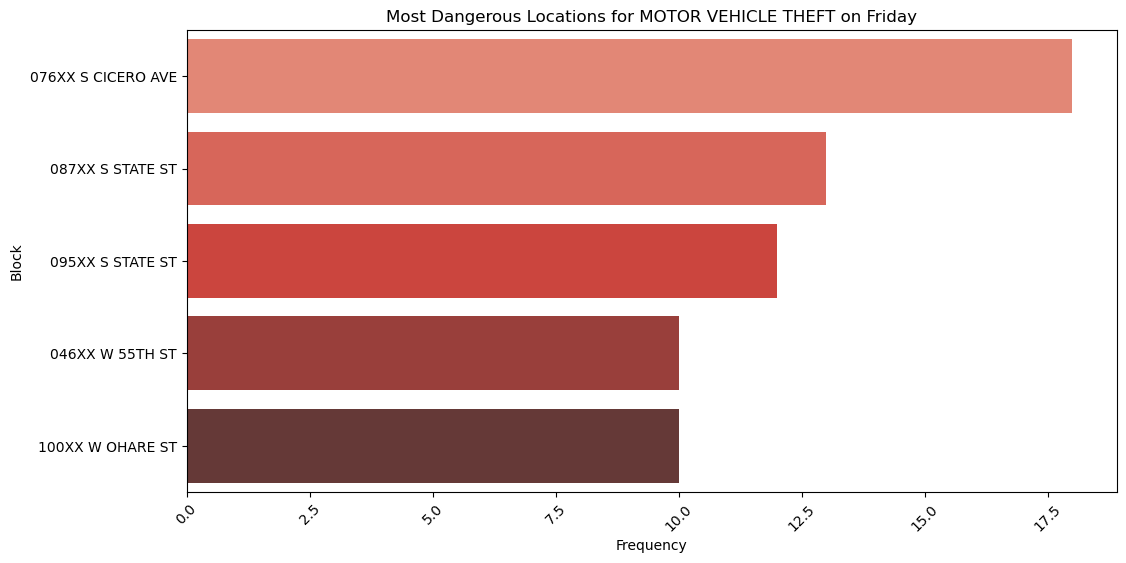

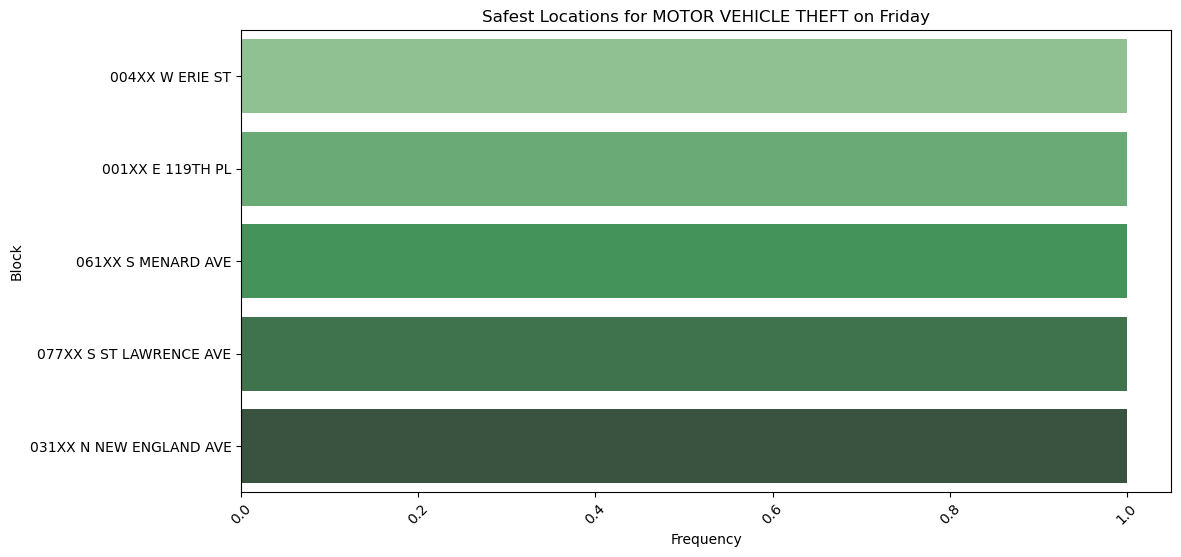

In [36]:
# Extract the day of the week from the "Date" column
chicago_crime_2001_to_2023_df["Day_of_Week"] = chicago_crime_2001_to_2023_df["Date"].dt.day_name()

# Filter data for MOTOR VEHICLE THEFT incidents
theft_data = chicago_crime_2001_to_2023_df[chicago_crime_2001_to_2023_df["Primary Type"] == "MOTOR VEHICLE THEFT"]

# Find the day with the highest occurrence

# .mode() function returns the most frequently occurring value(s) in the specified column.

# theft_data["Day_of_Week"].mode(): Calculates the mode of the "Day_of_Week" column.
# [0]: Retrieves the first (or only) value from the mode result, as the mode function can return multiple values if there is a tie.

# So, most_common_weekday will be the day of the week with the highest occurrence for MOTOR VEHICLE THEFT incidents. This value is then used to filter the data for that specific day (specific_day_theft) and identify the most dangerous and safest locations for MOTOR VEHICLE THEFT incidents on that day.
most_common_weekday = theft_data["Day_of_Week"].mode()[0]

# Filter data for the specific day (most common weekday)
specific_day_theft = theft_data[theft_data["Day_of_Week"] == most_common_weekday]

# Find the locations (blocks) with the highest number of MOTOR VEHICLE THEFT incidents
dangerous_locations = specific_day_theft["Block"].value_counts().head(5)

# Find the locations (blocks) with the lowest number of MOTOR VEHICLE THEFT incidents
safest_locations = specific_day_theft["Block"].value_counts(ascending=True).head(5)

# Create a bar plot to visualize the most dangerous and safest locations
plt.figure(figsize=(12, 6))
sns.barplot(x=dangerous_locations.values, y=dangerous_locations.index, palette="Reds_d")
plt.title(f"Most Dangerous Locations for MOTOR VEHICLE THEFT on {most_common_weekday}")
plt.xlabel("Frequency")
plt.ylabel("Block")
plt.xticks(rotation=45)


plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x=safest_locations.values, y=safest_locations.index, palette="Greens_d")
plt.title(f"Safest Locations for MOTOR VEHICLE THEFT on {most_common_weekday}")
plt.xlabel("Frequency")
plt.ylabel("Block")
plt.xticks(rotation=45)


plt.show()


Are there certain periods of the year/month/day/time of day where GTA is more frequent?

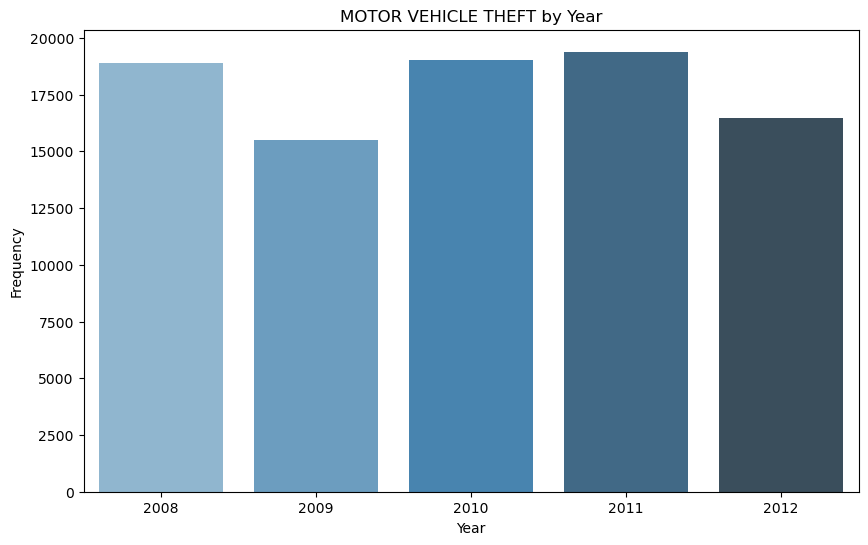

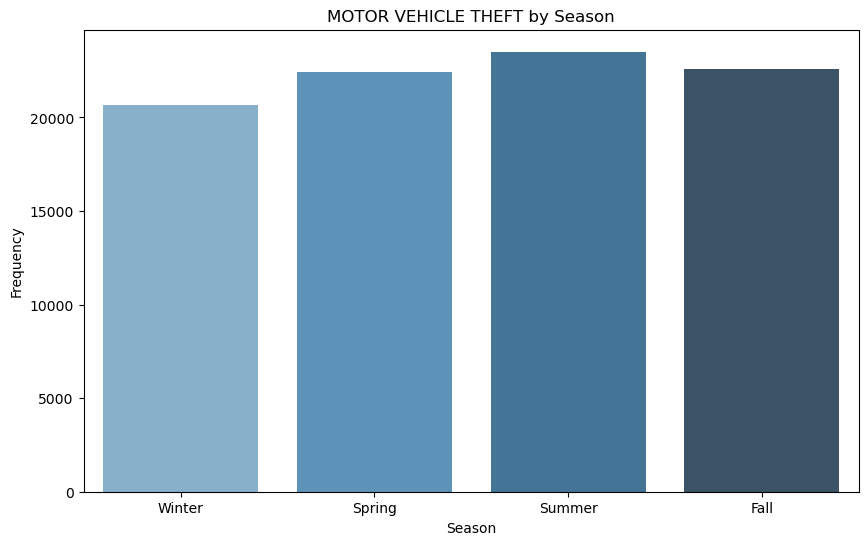

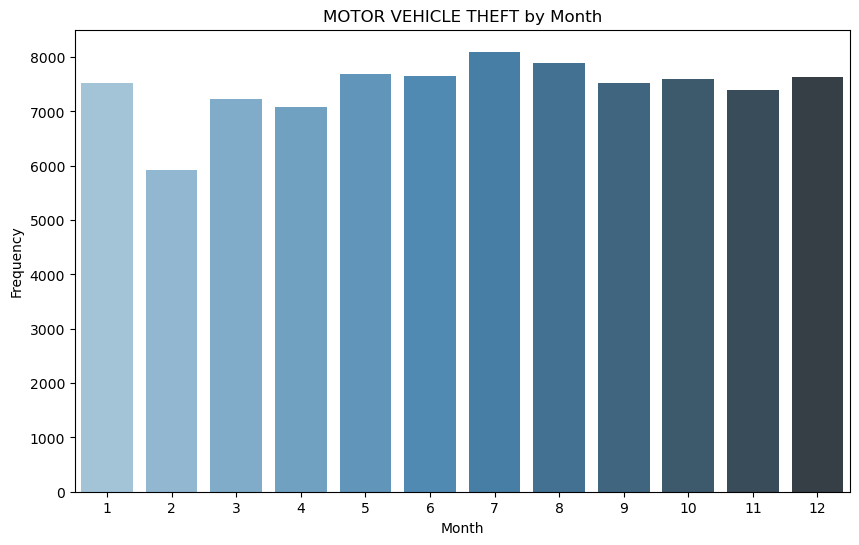

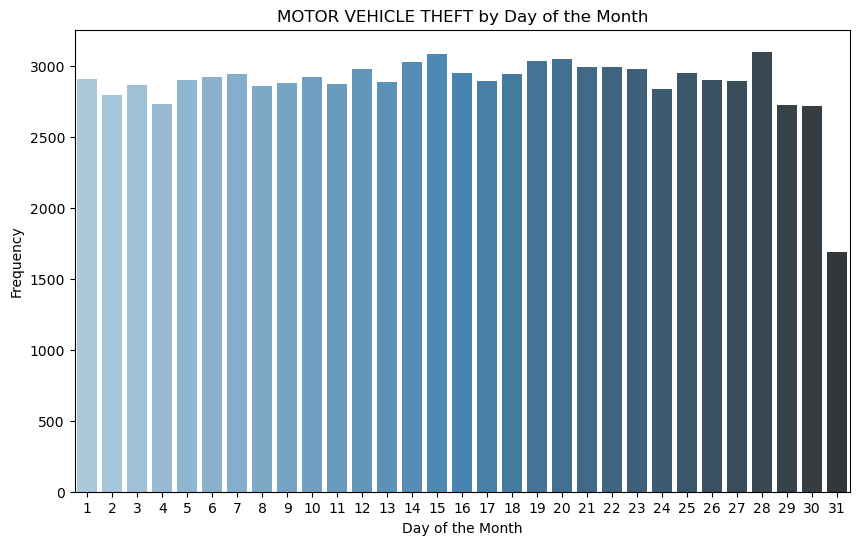

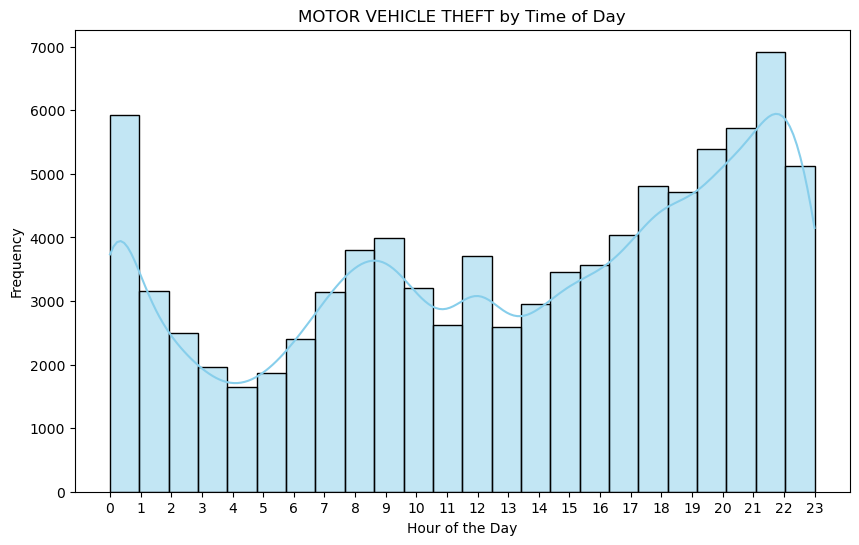

In [37]:
# Yearly-wise Analysis: 
theft_data["Year"] = theft_data["Date"].dt.year
theft_by_year = theft_data["Year"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=theft_by_year.index, y=theft_by_year.values, palette="Blues_d")
plt.title("MOTOR VEHICLE THEFT by Year")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()


# Seasonal-wise Analysis:

# Create a new column "Season"
# Define the season boundaries
# For example, Spring (March to May), Summer (June to August), Fall (September to November), Winter (December to February).

theft_data["Season"] = pd.cut(theft_data["Date"].dt.month, bins=[0, 3, 6, 9, 12], labels=["Winter", "Spring", "Summer", "Fall"])

# Visualize theft incidents by season
theft_by_season = theft_data["Season"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=theft_by_season.index, y=theft_by_season.values, palette="Blues_d")
plt.title("MOTOR VEHICLE THEFT by Season")
plt.xlabel("Season")
plt.ylabel("Frequency")
plt.show()



# Month-wise Analysis:
theft_data["Month"] = theft_data["Date"].dt.month
theft_by_month = theft_data["Month"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=theft_by_month.index, y=theft_by_month.values, palette="Blues_d")
plt.title("MOTOR VEHICLE THEFT by Month")
plt.xlabel("Month")
plt.ylabel("Frequency")
plt.show()

# Day-wise Analysis:
theft_data["Day_of_Month"] = theft_data["Date"].dt.day
theft_by_day = theft_data["Day_of_Month"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=theft_by_day.index, y=theft_by_day.values, palette="Blues_d")
plt.title("MOTOR VEHICLE THEFT by Day of the Month")
plt.xlabel("Day of the Month")
plt.ylabel("Frequency")
plt.show()

# Time of Day Analysis:
theft_data["Hour"] = theft_data["Date"].dt.hour
plt.figure(figsize=(10, 6))
sns.histplot(theft_data["Hour"], bins=24, kde=True, color="skyblue")
plt.title("MOTOR VEHICLE THEFT by Time of Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Frequency")
plt.xticks(range(24))
plt.show()


# 8 - The $ factor

Merge the crime and census datasets together in a suitable way.

In [41]:
# Merge the crime and census datasets using the column names
# Now, "merged_data" contains the combined information from both datasets.
merged_data = pd.merge(chicago_crime_2001_to_2023_df, chicago_census_2008_to_2012_df, left_on="Community Area", right_on="Community Area Number", how="inner")




Are there certain kinds of socoeconomic area that are more prone to certain kinds of crimes? We will do a deep dive.

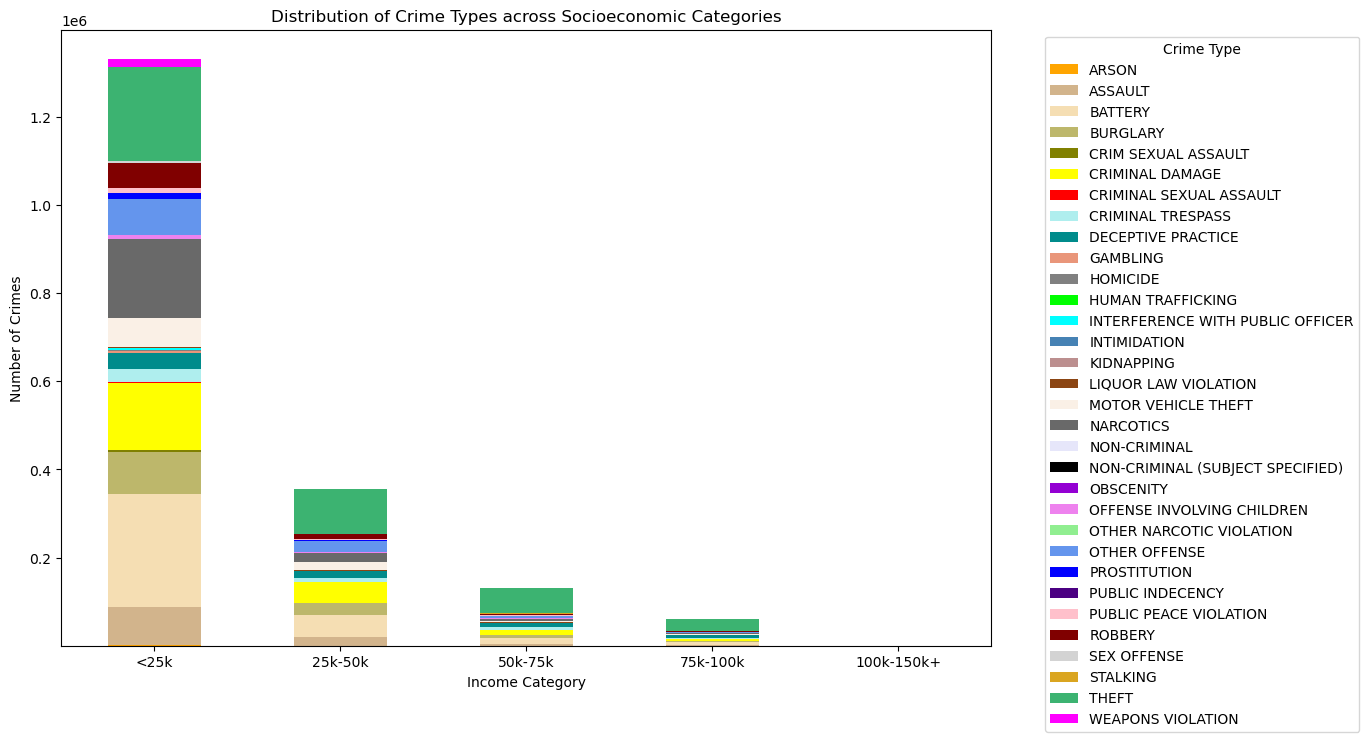

In [42]:
# Filter relevant columns for analysis
selected_columns = ["PER CAPITA INCOME ", "Primary Type"]

# Drop rows with missing values in selected columns
selected_data = merged_data[selected_columns].dropna()

# Categorize income levels

# pd.cut function from pandas to categorize the values in the "PER CAPITA INCOME" column into discrete bins. The bins parameter specifies the bin edges, and the labels parameter specifies the labels for each bin.

income_bins = [0, 25000, 50000, 75000, 100000, 150000]
income_labels = ["<25k", "25k-50k", "50k-75k", "75k-100k", "100k-150k+"]
selected_data["Income Category"] = pd.cut(selected_data["PER CAPITA INCOME "], bins=income_bins, labels=income_labels)

# Group data by income category and crime type, count occurrences
grouped_data = selected_data.groupby(["Income Category", "Primary Type"]).size().unstack()


# Define unique colors for each crime type
custom_colors = {
    "ARSON": "orange",
    "ASSAULT": "tan",
    "BATTERY": "wheat",
    "BURGLARY": "darkkhaki",
    "CRIM SEXUAL ASSAULT": "olive",
    "CRIMINAL DAMAGE": "yellow",
    "CRIMINAL SEXUAL ASSAULT": "red",
    "CRIMINAL TRESPASS": "paleturquoise",
    "DECEPTIVE PRACTICE": "darkcyan",
    "GAMBLING": "darksalmon",
    "HOMICIDE": "grey",
    "HUMAN TRAFFICKING": "lime",
    "INTERFERENCE WITH PUBLIC OFFICER": "cyan",
    "INTIMIDATION": "steelblue",
    "KIDNAPPING": "rosybrown",
    "LIQUOR LAW VIOLATION": "saddlebrown",
    "MOTOR VEHICLE THEFT": "linen",
    "NARCOTICS": "dimgray",
    "NON-CRIMINAL": "lavender",
    "NON-CRIMINAL (SUBJECT SPECIFIED)": "black",
    "OBSCENITY": "darkviolet",
    "OFFENSE INVOLVING CHILDREN": "violet",
    "OTHER NARCOTIC VIOLATION": "lightgreen",
    "OTHER OFFENSE": "cornflowerblue",
    "PROSTITUTION": "blue",
    "PUBLIC INDECENCY": "indigo",
    "PUBLIC PEACE VIOLATION": "pink",
    "ROBBERY": "maroon",
    "SEX OFFENSE": "lightgrey",
    "STALKING": "goldenrod",
    "THEFT": "mediumseagreen",
    "WEAPONS VIOLATION": "magenta",
}

# Map crime type names to colors, use a default color if a crime type is missing
colors = [custom_colors.get(crime_type, "black") for crime_type in grouped_data.columns]

# Plot stacked bar chart with custom colors for each crime type

# bbox_to_anchor=(1.05, 1): This parameter specifies the anchor point for placing the legend outside the plot area. The (1.05, 1) coordinates mean that the legend will be placed slightly to the right (1.05) and above (1) the plot area. 

grouped_data.plot(kind="bar", stacked=True, figsize=(12, 8), color=colors)
plt.title("Distribution of Crime Types across Socioeconomic Categories")
plt.xlabel("Income Category")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=0)
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


# 9 - Spotligt on!

There are obviously so much more to gain by analysing these datasets. Recall that the census data contributed with **alot** of dimensions.

#### **Crime types across different educational attainment levels**

What is the distribution of crime types across different educational attainment levels?

How does the data look after merging crime and education datasets?

In [43]:
# Create sample crime data using a DataFrame
Merged_data = pd.DataFrame({"Community Area": [1, 2, 3, 1, 2],
                            "Primary Type": ["Theft", "Assault", "Robbery", "Assault", "Theft"]})
# Create sample census data using another DataFrame
census_data = pd.DataFrame({"Community Area Number": [1, 2, 3],
                            "EDUCATIONAL ATTAINMENT": ["High School", "College", "Bachelor"],
                            "PER CAPITA INCOME ": [30000, 45000, 60000]})


# Merge crime and education datasets based on the Community Area
merged_data_education = pd.merge(Merged_data, census_data, left_on="Community Area", right_on="Community Area Number", how="inner")
# Display the merged dataset
print(merged_data_education)


   Community Area Primary Type  Community Area Number EDUCATIONAL ATTAINMENT  \
0               1        Theft                      1            High School   
1               1      Assault                      1            High School   
2               2      Assault                      2                College   
3               2        Theft                      2                College   
4               3      Robbery                      3               Bachelor   

   PER CAPITA INCOME   
0               30000  
1               30000  
2               45000  
3               45000  
4               60000  


What columns are selected for analysis, and how are missing values handled?

In [44]:
# Selecting relevant columns and handling missing values
selected_columns_education = ["EDUCATIONAL ATTAINMENT", "Primary Type"]
selected_data_education = merged_data_education[selected_columns_education].dropna()


How is the data grouped, and what does the stacked bar chart represent?

<Axes: xlabel='EDUCATIONAL ATTAINMENT'>

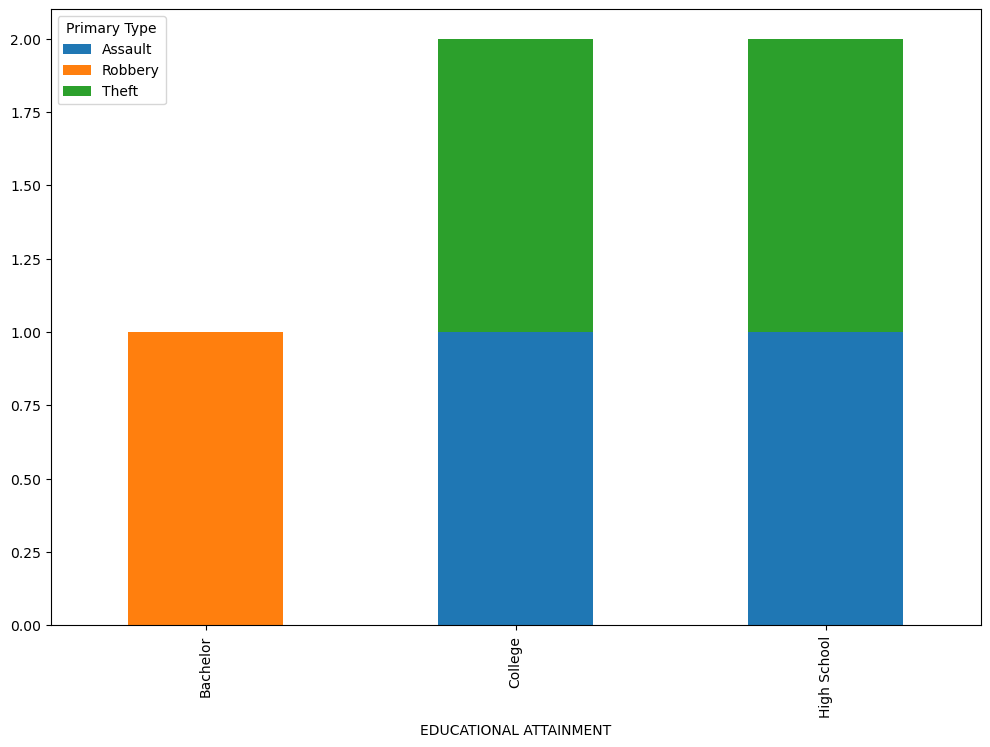

In [45]:
# Grouping data and creating a stacked bar chart
grouped_data_education = selected_data_education.groupby(["EDUCATIONAL ATTAINMENT", "Primary Type"]).size().unstack()
grouped_data_education.plot(kind="bar", stacked=True, figsize=(12, 8))


What labels and legend are added to enhance the chart?

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


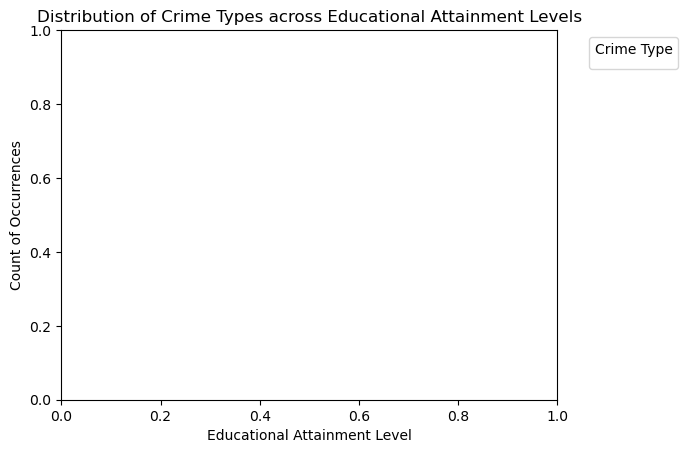

In [46]:
# Adding labels and legend to the chart
plt.title("Distribution of Crime Types across Educational Attainment Levels")
plt.xlabel("Educational Attainment Level")
plt.ylabel("Count of Occurrences")
plt.xticks(rotation=0)
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


The code assembled

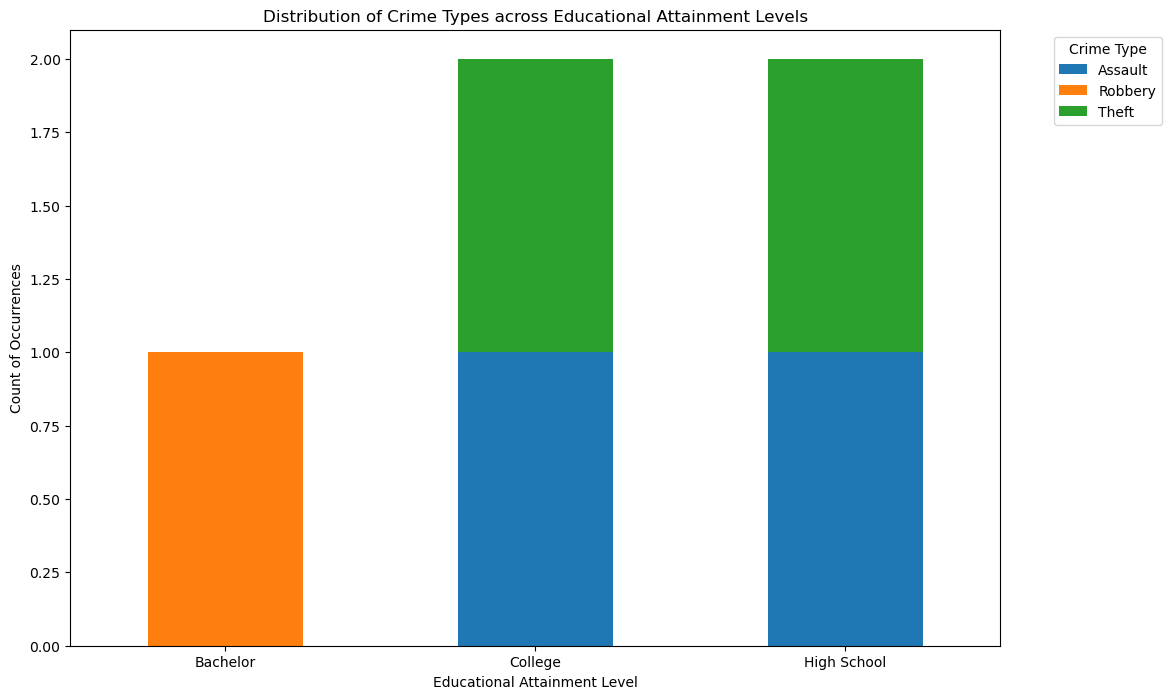

In [47]:
# Sample data, replace with your actual datasets
Merged_data = pd.DataFrame({"Community Area": [1, 2, 3, 1, 2],
                            "Primary Type": ["Theft", "Assault", "Robbery", "Assault", "Theft"]})

census_data = pd.DataFrame({"Community Area Number": [1, 2, 3],
                            "EDUCATIONAL ATTAINMENT": ["High School", "College", "Bachelor"],
                            "PER CAPITA INCOME ": [30000, 45000, 60000]})

# Merging crime and education datasets
merged_data_education = pd.merge(Merged_data, census_data, left_on="Community Area", right_on="Community Area Number", how="inner")

# Selecting relevant columns and handling missing values
selected_columns_education = ["EDUCATIONAL ATTAINMENT", "Primary Type"]
selected_data_education = merged_data_education[selected_columns_education].dropna()

# Grouping data and creating a stacked bar chart
grouped_data_education = selected_data_education.groupby(["EDUCATIONAL ATTAINMENT", "Primary Type"]).size().unstack()
grouped_data_education.plot(kind="bar", stacked=True, figsize=(12, 8))

# Adding labels and legend to the chart
plt.title("Distribution of Crime Types across Educational Attainment Levels")
plt.xlabel("Educational Attainment Level")
plt.ylabel("Count of Occurrences")
plt.xticks(rotation=0)
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()



Analysis Summary:

* The prevalent primary crime types associated with different educational attainment levels reveal distinctive patterns. Individuals with a bachelor's degree tend to be more frequently involved in robbery incidents. On the other hand, those with only college and high school degrees exhibit a notable occurrence of both assault and theft. It is noteworthy that the overall count of crimes involving individuals with college and high school degrees is higher compared to those with bachelor's degrees.

# 10 - A moment of reflection

Looking back at the analysis that we've done, what do you think about it? Specifically, how reliable are our conclusions? Is there anything that could be done to improve the factuality of the analysis? If so, what?

#### Analysis Reflection


It is imperative to acknowledge both the merits and constraints of the analysis. The inferences drawn from this study hinge on the available data and assumptions made throughout the analytical process. The reliability of these inferences is contingent upon the quality and representativeness of the datasets used.

**Merits:**

    * The analysis provides valuable insights into the interplay of socioeconomic factors, education, and crime types.
    * Effective visualizations convey discernible patterns and trends.
    * Utilization of census data contributes to a comprehensive understanding of the socioeconomic landscape.


**Constraints:**

    * Correlation does not imply causation; observed relationships may be influenced by various confounding factors.
    * Reliance on reported crime data introduces the potential for underreporting or biases.
    * Socioeconomic factors are intricate, and selected variables may not encapsulate the full complexity of communities.
    * Educational attainment data may not fully encapsulate the educational dynamics within a community.


**Recommendations for Enhancement:**

    * Employing advanced statistical analyses for a deeper exploration of correlations.
    * Incorporating additional socioeconomic variables to enrich the depth of analysis.
    * Validating findings through external sources and considering alternative datasets.
    * Continuously refining and validating the analysis, while considering external factors, can bolster the factual accuracy and robustness of the conclusions. Involving domain experts and stakeholders can offer valuable perspectives for a more comprehensive understanding.

**Performance Optimization:**

    * Crucial for handling large datasets, performance enhancement through techniques like vectorization or chunking, and utilizing libraries like NumPy or Cython, significantly expedites processes. In this program, efforts were made to optimize performance, focusing on both speed and memory consumption.


**Data Safeguards and Anonymization:**

    * While not directly tied to this dataset, considerations for safeguarding and anonymization are essential. Thoughtful handling of missing values is necessary, understanding whether they result from oversight, intentional omission, or non-existence. Removing missing values, when appropriate, ensures the protection of individuals' personal information, a consideration upheld during the analysis.